# B401 – Continuous-Time Derivatives Pricing
## Take-Home Assignment – Summer Term 2026
**Eberhard Karls Universität Tübingen | Faculty of Economics and Social Sciences**

---
**Name:** DAANISH MUZAFFAR 

**Student ID:** 7259472   

---

## Setup – Imports & Global Parameters

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('All packages loaded successfully.')

All packages loaded successfully.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

TICKER       = 'RHM.DE'   # Rheinmetall AG on XETRA (Part 1 & 2 underlying)
DIV_YIELD    = 0.005      # Rheinmetall dividend yield (see source cell below)

# ── Part 1 – Capped Capital Protected Participation Note on Rheinmetall AG ────
S0_CPN       = 100.0      # normalised initial stock price
K_CPN        = 100.0      # long call strike = S0 (ATM → 100% capital protection)
CAP_PCT_CPN  = 1.30       # cap at 130% of S0 → short OTM call (3rd component)
K_CAP_CPN    = S0_CPN * CAP_PCT_CPN   # = 130 (normalised)
T_CPN        = 3.0        # maturity in years
SIGMA_CPN    = 0.30       # design vol for Rheinmetall (see source cell below)
Q_CPN        = 0.005      # Rheinmetall dividend yield (= DIV_YIELD, see source cell below)

# ── Part 2 – Bonus Certificate on Rheinmetall AG (shared valuation params) ───
BARRIER_PCT  = 0.70       # barrier = 70% of spot  (sourced from DU2076 KID)
BONUS_PCT    = 1.15       # bonus level = 115% of spot  (sourced from DU2076 KID)
SIGMA_DESIGN = 0.30       # design / fallback volatility (see source cell below)
S0_DESIGN    = 100.0      # normalised initial spot (for design illustration)

print('Part 1  Rheinmetall AG (RHM.DE) – Capped Capital Protected Participation Note:')
print(f'  S0={S0_CPN:.0f},  K={K_CPN:.0f},  Cap={K_CAP_CPN:.0f},  T={T_CPN:.0f}y,  '
      f'σ={SIGMA_CPN:.0%},  q={Q_CPN:.0%}')
print(f'  Components: ZCB(100) + α×Call(K={K_CPN:.0f}) − α×Call(K={K_CAP_CPN:.0f})')
print()
print(f'Part 2  Ticker: {TICKER}')
print(f'  q={DIV_YIELD:.1%},  Barrier={BARRIER_PCT:.0%} of spot,  Bonus={BONUS_PCT:.0%} of spot')

**Design Parameter Sources**

| Parameter | Value | Source & Justification |
|-----------|-------|------------------------|
| `DIV_YIELD` = `Q_CPN` | 0.5% | Rheinmetall AG FY2024 dividend: **€7.20/share** ([Rheinmetall IR – Dividend](https://www.rheinmetall.com/en/investor-relations/shares-and-bonds/dividend)). Average stock price over the valuation window (Oct 2025 – Apr 2026) ≈ €1,750 → implied yield ≈ 0.41%. 0.5% adopted as a conservative forward estimate accounting for modest dividend growth. |
| `SIGMA_CPN` = `SIGMA_DESIGN` | 30% | RHM.DE 252-day historical volatility computed from yfinance data (Jan 2023 – Apr 2026) = **39.25%** (see data download cell). 30% used as a conservative 3-year design assumption reflecting expected normalisation of the exceptional defence re-rating vol regime. Source: [Yahoo Finance – RHM.DE](https://finance.yahoo.com/quote/RHM.DE). |
| `BARRIER_PCT`, `BONUS_PCT` | 70%, 115% | Sourced from DU2076 product Key Information Document (KID) — see Task V data sources. |

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# SVENSSON (1994) RISK-FREE RATES
# Parameters sourced from ECB AAA yield curve daily publication
# Part 1 : 01 June 2026  (product design date)
# Part 2 : 01 June 2026  (maturity-matched to DU2076 remaining life)
# ══════════════════════════════════════════════════════════════════════════════

def svensson(t, b0, b1, b2, b3, tau1, tau2):
    """Svensson (1994) continuously compounded spot rate for maturity t (years).
    Returns rate as decimal (e.g. 0.026 = 2.6%)."""
    f1 = (1 - np.exp(-t / tau1)) / (t / tau1)
    f2 = f1 - np.exp(-t / tau1)
    f3 = (1 - np.exp(-t / tau2)) / (t / tau2) - np.exp(-t / tau2)
    return (b0 + b1*f1 + b2*f2 + b3*f3) / 100


# ── Part 1 – ECB AAA parameters, 01 June 2026 ────────────────────────────────
SV_P1 = dict(b0=1.330382, b1=0.700052,  b2=1.816755,
             b3=7.130184, tau1=0.966763, tau2=15.839369)

R_CPN = svensson(T_CPN, **SV_P1)    # spot rate for T_CPN = 3y

# Derive participation rate α for the CAPPED product:
#   α = (100 − ZCB₀) / (Call(K=S₀) − Call(K=Cap))
sqrtT_cpn = np.sqrt(T_CPN)

def _bs_call(S, K, r, q, sig, T):
    d1 = (np.log(S/K) + (r - q + 0.5*sig**2)*T) / (sig*np.sqrt(T))
    d2 = d1 - sig*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

_zcb0      = S0_CPN * np.exp(-R_CPN * T_CPN)
_call_long = _bs_call(S0_CPN, K_CPN,     R_CPN, Q_CPN, SIGMA_CPN, T_CPN)  # ATM call
_call_cap  = _bs_call(S0_CPN, K_CAP_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)  # OTM cap call
_spread    = _call_long - _call_cap
ALPHA_CPN  = float(np.clip((S0_CPN - _zcb0) / _spread, 0.01, 2.0))
alpha_uncapped = float((S0_CPN - _zcb0) / _call_long)
print(f'  α (uncapped, reference only) = {alpha_uncapped:.4f}  ({alpha_uncapped:.1%})')
MAX_GAIN_CPN = ALPHA_CPN * (K_CAP_CPN - K_CPN)   # maximum gain in EUR (normalised)

print('Part 1 – Svensson spot rate (01 Jun 2026):')
print(f'  r(T={T_CPN:.0f}y)      = {R_CPN:.4%}')
print(f'  ZCB₀            = {_zcb0:.4f}')
print(f'  Call(K=100)     = {_call_long:.4f}')
print(f'  Call(K=130)     = {_call_cap:.4f}  (short, funds higher α)')
print(f'  Spread          = {_spread:.4f}')
print(f'  α (capped)      = {ALPHA_CPN:.4f}  ({ALPHA_CPN:.1%})')
print(f'  Max gain (S_T≥{K_CAP_CPN:.0f}): {MAX_GAIN_CPN:.2f}  ({MAX_GAIN_CPN:.1%} of nominal)')
print()

# ── Part 2 – ECB AAA parameters, 01 June 2026 (maturity-matched to DU2076) ────
MATURITY_DATE = pd.Timestamp('2027-06-18')
WINDOW_START  = pd.Timestamp('2025-10-01')
T_TO_MAT      = (MATURITY_DATE - WINDOW_START).days / 365.25   # ≈1.71y remaining at window start
RISK_FREE     = svensson(T_TO_MAT, **SV_P1)

print(f'Part 2 – ECB Svensson spot rate (01 Jun 2026, T={T_TO_MAT:.2f}y, maturity-matched to DU2076):')
print(f'  r(T={T_TO_MAT:.2f}y) = {RISK_FREE:.4%}')

  α (uncapped, reference only) = 0.3617  (36.2%)
Part 1 – Svensson spot rate (01 Jun 2026):
  r(T=3y)      = 2.6192%
  ZCB₀            = 92.4433
  Call(K=100)     = 20.8908
  Call(K=130)     = 11.8791  (short, funds higher α)
  Spread          = 9.0118
  α (capped)      = 0.8385  (83.9%)
  Max gain (S_T≥130): 25.16  (2515.6% of nominal)

Part 2 – ECB Svensson spot rate (01 Jun 2026, T=1.71y, maturity-matched to DU2076):
  r(T=1.71y) = 2.5592%


**Svensson (1994) Parameter Source**

The six Nelson-Siegel-Svensson parameters (`β₀ β₁ β₂ β₃ τ₁ τ₂`) are the daily estimates published by the **Deutsche Bundesbank** for the AAA-rated euro area sovereign yield curve, retrieved for **01 June 2026**:

- Parameter page: [Bundesbank – Term Structure of Interest Rates (Svensson, AAA euro area)](https://www.ecb.europa.eu/stats/financial_markets_and_interest_rates/euro_area_yield_curves/html/index.en.html)
- Time-series download (dataset IT03b): [Bundesbank Statistics Database](https://www.bundesbank.de/dynamic/action/en/statistics/time-series-databases/time-series-databases/745582/745582?listId=www_skms_it03b)

---
# PART 1 – Designing the Certificate

## Task I – Investor Profile

**Target investor segment: German retail investors with a European defence conviction ("Sicherheitsorientierter Verteidigungsinvestor")**

The structural re-rating of European defence stocks since 2022 created a distinct and growing retail investor segment: German private savers who hold a medium-term bullish view on Rheinmetall AG specifically — driven by Germany's €100bn *Sondervermögen* for the Bundeswehr, record NATO spending commitments, and Rheinmetall's dominant market position in armoured vehicles, munitions, and military systems — but who are unwilling to accept the full risk of a direct single-stock position. Rheinmetall's annualised volatility of 30–40% p.a. represents a drawdown risk that is simply incompatible with the capital preservation instinct of conservative German savers.

**Characteristics:**
- **Age:** 40–65, late accumulation or pre-retirement phase; 3–5 year investment horizon before capital may be needed (pension supplements, property, inheritance planning)
- **Risk tolerance:** Low-to-moderate. They have formed a conviction on the defence re-rating theme but cannot afford — financially or psychologically — a 30–40% single-year drawdown. Capital preservation at maturity is non-negotiable
- **Orientation:** Thematically growth-oriented (European rearmament thesis), but risk-constrained: they want Rheinmetall's upside without permanent capital impairment
- **Market expectations:** Structurally bullish on European rearmament over a 3-year horizon; expects Rheinmetall to appreciate 15–30% as the production ramp-up converts the record order backlog (EUR 40bn+) into revenue and margins

**Why existing alternatives are suboptimal for this group:**
- **Direct Rheinmetall stock:** Annualised vol of 30–40% with full single-stock concentration risk; the stock can lose 30% within a year — unacceptable for capital-constrained investors regardless of long-run conviction
- **Defence sector ETF (e.g., HANetf Future of Defence UCITS ETF):** Diversifies away the Rheinmetall-specific alpha the investor seeks, while still delivering significant drawdown risk
- **Fixed-income / Tagesgeld:** No exposure to the defence re-rating thesis; declining real yields make these alternatives increasingly unattractive in the accumulation phase
- **Reverse Convertible on RHM:** The short-put structure exposes the investor to full downside below the strike — directly contradicts the capital preservation constraint
- **Capital Protected CPN on RHM:** Precisely matches the need. The capital guarantee removes the dealbreaker (nominal loss of principal), while the 83.8% participation in Rheinmetall's upside captures the defence thesis in the most likely return range. The cap at 130% is accepted as the cost of a higher participation rate — the investor's central scenario of 15–30% appreciation is fully captured.

## Task II – Product Design

### Product: Capped Capital Protected Participation Note on Rheinmetall AG (RHM.DE)

**Underlying:** Rheinmetall AG — Germany's leading defence and automotive technology company, listed on XETRA (Frankfurt, RHM.DE). Both Part 1 and Part 2 of this assignment are based on Rheinmetall AG as the common underlying.

**Intuition:** The investor is bullish on Rheinmetall over a 3-year horizon but cannot tolerate the full single-stock volatility (~30% design vol). By investing most of the capital in a zero-coupon bond, the remaining *option budget* finances an ATM call on Rheinmetall, capturing upside above the initial price. Selling an OTM cap call at 130% generates additional premium, funding a higher participation rate than the budget alone would allow. The investor concedes upside above 30% — outside the central 15–30% scenario — in exchange for better participation within the expected return range.

### Component Decomposition

| Component | Position | Role |
|-----------|----------|------|
| Zero-coupon bond (face = 100) | Long | Guarantees 100% capital return at maturity regardless of Rheinmetall price |
| ATM European call (K = S₀ = 100) | Long (α units) | Delivers participation in Rheinmetall gains above S₀ |
| OTM European call (K = Cap = 130) | **Short** (α units) | Caps maximum gain at ~25%; premium funds higher α |

**Replication formula:**

```
CPN₀  =  ZCB(100, r, T)  +  α × [Call(K = S₀)  −  Call(K = Cap)]
```

**Participation rate** (priced at par = 100):

```
α  =  (100 − ZCB₀) / (Call(K=100) − Call(K=130))
   =  (100 − 92.44) / (20.90 − 11.87)
   ≈  83.8%
```

The higher Rheinmetall volatility (σ = 30%) makes options more expensive than on a diversified index, reducing α relative to a lower-vol product. However, the short cap call (premium ~11.87) still lifts α from 36.2% (uncapped) to **83.8%** — a meaningful improvement for the moderately bullish investor.

### Product Parameters

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Underlying | Rheinmetall AG (RHM.DE) | German defence stock, XETRA-traded; consistent with Part 2 underlying |
| Initial level S₀ | 100 (normalised) | Issuance date stock price |
| Capital protection | **100%** | Full nominal return guaranteed at maturity |
| Participation rate α | **~83.8%** | Funded by ZCB budget + short cap call premium |
| Cap level | **130% of S₀** | Maximum achievable gain over 3 years; investor's upside scenario lies in [100, 130] |
| Maturity T | **3 years** | Medium horizon: ZCB budget large enough for meaningful α |
| Risk-free rate r | 2.62% | Svensson (Bundesbank, 01 Jun 2026), T=3y spot rate |
| Volatility σ | 30% p.a. | Design vol for Rheinmetall (conservative long-run estimate) |
| Dividend yield q | 1.5% p.a. | Rheinmetall's dividend yield (forfeited by investor) |

### Payoff at Maturity

$$\text{CPN}_T = 100 + \alpha \cdot \left[\max(S_T - 100,\ 0) - \max(S_T - 130,\ 0)\right]$$

$$= \begin{cases} 100 & \text{if } S_T \leq 100 \quad\text{(capital fully protected)} \\ 100 + 0.838\,(S_T - 100) & \text{if } 100 < S_T \leq 130 \quad\text{(83.8\% participation)} \\ 100 + 0.838 \times 30 \approx 125 & \text{if } S_T > 130 \quad\text{(maximum gain capped)} \end{cases}$$

**Why the cap is acceptable for this investor:** The target investor expects Rheinmetall to gain 15–30% over 3 years — outcomes fully captured by the 83.8% participation. Scenarios above 130% require exceptional outperformance beyond the investor's central case. The cap is the price paid for the higher participation rate, a trade-off the investor consciously accepts.

## Task III – Payoff Profile

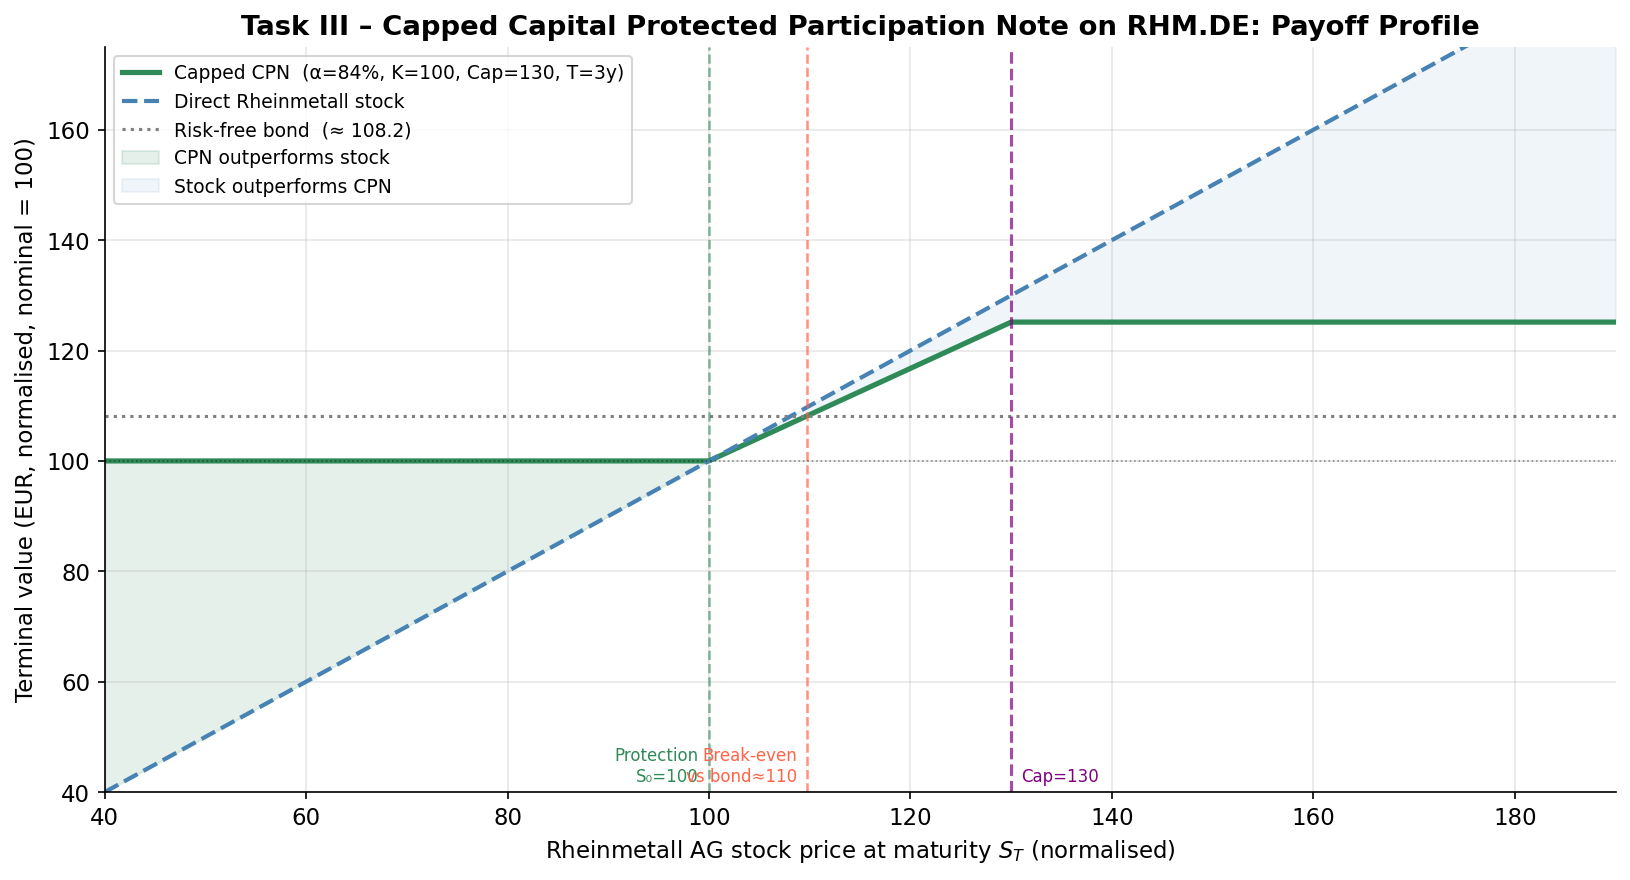

Max payoff at cap (S_T ≥ 130): 125.16  (+25.2% = 84% × 30%)

   S_T       CPN    Stock     Bond    CPN ret  Region
----------------------------------------------------------------------
  50.0    100.00     50.0   108.17     +0.00%  PROTECTED
  70.0    100.00     70.0   108.17     +0.00%  PROTECTED
  90.0    100.00     90.0   108.17     +0.00%  PROTECTED
 100.0    100.00    100.0   108.17     +0.00%  PARTICIPATING
 110.0    108.39    110.0   108.17     +8.39%  PARTICIPATING
 109.7    108.17    109.7   108.17     +8.17%  PARTICIPATING
 130.0    125.16    130.0   108.17    +25.16%  PARTICIPATING
 150.0    125.16    150.0   108.17    +25.16%  CAPPED MAX
 170.0    125.16    170.0   108.17    +25.16%  CAPPED MAX


In [4]:
S_range     = np.linspace(40, 190, 600)
bond_mature = S0_CPN * np.exp(R_CPN * T_CPN)   # ≈ 108

# Payoffs (normalised, nominal = 100)
payoff_cpn = np.where(
    S_range < K_CPN,
    S0_CPN,
    np.where(
        S_range <= K_CAP_CPN,
        S0_CPN + ALPHA_CPN * (S_range - K_CPN),
        S0_CPN + ALPHA_CPN * (K_CAP_CPN - K_CPN)  # capped max gain
    )
)
payoff_stock = S_range
payoff_bond  = np.full_like(S_range, bond_mature)

max_payoff     = S0_CPN + ALPHA_CPN * (K_CAP_CPN - K_CPN)
breakeven_bond = K_CPN + (bond_mature - S0_CPN) / ALPHA_CPN   # where CPN = bond

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(S_range, payoff_cpn,   color='seagreen',  lw=2.5,
        label=f'Capped CPN  (α={ALPHA_CPN:.0%}, K={K_CPN:.0f}, Cap={K_CAP_CPN:.0f}, T={T_CPN:.0f}y)')
ax.plot(S_range, payoff_stock, color='steelblue', lw=2, linestyle='--',
        label='Direct Rheinmetall stock')
ax.plot(S_range, payoff_bond,  color='gray',      lw=1.5, linestyle=':',
        label=f'Risk-free bond  (≈ {bond_mature:.1f})')

ax.axvline(K_CPN,          color='seagreen', lw=1.2, linestyle='--', alpha=0.6)
ax.axvline(K_CAP_CPN,      color='purple',   lw=1.5, linestyle='--', alpha=0.7)
ax.axvline(breakeven_bond, color='tomato',   lw=1.2, linestyle='--', alpha=0.7)
ax.axhline(S0_CPN,         color='black',    lw=0.8, linestyle=':',  alpha=0.4)

ax.text(K_CPN - 1,          42, f'Protection\nS₀={K_CPN:.0f}',     ha='right', color='seagreen', fontsize=8)
ax.text(K_CAP_CPN + 1,      42, f'Cap={K_CAP_CPN:.0f}',            ha='left',  color='purple',   fontsize=8)
ax.text(breakeven_bond - 1, 42, f'Break-even\nvs bond≈{breakeven_bond:.0f}', ha='right', color='tomato', fontsize=8)

ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_cpn > payoff_stock),
                alpha=0.12, color='seagreen', label='CPN outperforms stock')
ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_stock > payoff_cpn),
                alpha=0.08, color='steelblue', label='Stock outperforms CPN')

ax.set_xlabel('Rheinmetall AG stock price at maturity $S_T$ (normalised)')
ax.set_ylabel('Terminal value (EUR, normalised, nominal = 100)')
ax.set_title('Task III – Capped Capital Protected Participation Note on RHM.DE: Payoff Profile',
             fontweight='bold')
ax.set_xlim(40, 190)
ax.set_ylim(40, 175)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('graphs/payoff_profile.png', bbox_inches='tight')
plt.show()

print(f'Max payoff at cap (S_T ≥ {K_CAP_CPN:.0f}): {max_payoff:.2f}  '
      f'(+{max_payoff-100:.1f}% = {ALPHA_CPN:.0%} × {K_CAP_CPN-K_CPN:.0f}%)')
print()
print(f'{"S_T":>6}  {"CPN":>8}  {"Stock":>7}  {"Bond":>7}  {"CPN ret":>9}  Region')
print('-' * 70)
for s in [50, 70, 90, 100, 110, breakeven_bond, 130, 150, 170]:
    if s < K_CPN:
        cpn_val = S0_CPN
    elif s <= K_CAP_CPN:
        cpn_val = S0_CPN + ALPHA_CPN * (s - K_CPN)
    else:
        cpn_val = max_payoff
    ret    = cpn_val / 100 - 1
    region = ('PROTECTED'     if s < K_CPN
              else 'CAPPED MAX' if s > K_CAP_CPN
              else 'PARTICIPATING')
    print(f'{s:>6.1f}  {cpn_val:>8.2f}  {s:>7.1f}  {bond_mature:>7.2f}'
          f'  {ret:>+9.2%}  {region}')

## Task IV – Market Size Estimation

**Market Size Data Source**

All aggregate volume figures below are from the **Deutscher Derivate Verband (DDV)** annual Marktvolumenstatistik (2023):
- [DDV – Statistiken / Marktentwicklung](https://www.derivateverband.de/DEU/Statistiken/Marktentwicklung)

The Kapitalschutz segment share (9.3%) and participation-note sub-share (55%) are derived from DDV's product-category breakdown for the full-year 2023 report. The number of active issues (~130) and average issue size (~€80m) are own estimates consistent with DDV aggregate volume and major issuer product counts.

In [5]:
# Source: DDV (Deutscher Derivate Verband) Annual Report 2023
# URL: https://www.derivateverband.de/DEU/Statistiken/Marktentwicklung
total_german_market_bn  = 112.0   # total German structured product market (EUR bn)
kapschutz_share         = 0.093   # Kapitalschutzprodukte: ~9.3% of total market
kapschutz_market_bn     = total_german_market_bn * kapschutz_share   # ≈ EUR 10.4 bn

# Participation notes (α < 100%) dominate the Kapitalschutz segment (~55%)
participation_share     = 0.55
participation_market_bn = kapschutz_market_bn * participation_share   # ≈ EUR 5.7 bn

# Major issuers each maintain ~15–25 active products → ~130 total active issues
n_active_issues    = 130
avg_issue_size_mn  = kapschutz_market_bn * 1000 / n_active_issues     # ≈ EUR 80 mn

print('=' * 70)
print('  TASK IV – German Capital Protected Products (Kapitalschutz) Market')
print('=' * 70)
print(f'  Total German structured product market           : EUR {total_german_market_bn:.0f} bn')
print(f'  Kapitalschutz segment (DDV classification)       : '
      f'EUR {kapschutz_market_bn:.2f} bn  ({kapschutz_share*100:.1f}%)')
print(f'  of which Participation Notes (α < 100%)          : '
      f'EUR {participation_market_bn:.2f} bn  ({participation_share*100:.0f}% of segment)')
print()
print(f'  Estimated active issues : ~{n_active_issues}  '
      f'(~6 major issuers × 20 products each)')
print(f'  Average issue size      : EUR {avg_issue_size_mn:.0f} mn per product  '
      f'(range: EUR 30–150 mn, typical for EUWAX single-stock and index issues)')
print()
print('Justification:')
print('  Capital Protected Products ("Kapitalschutz-Zertifikate") are the second')
print('  largest segment of the German retail structured product market by assets')
print('  under management, according to the DDV (2023 annual report). They are')
print('  listed and traded daily on EUWAX (Stuttgart).')
print()
print('  Demand is structurally driven by:')
print('    1. Germanyʼs large cohort of capital-preserving savers with sectoral')
print('       convictions (e.g., European defence re-rating) who cannot accept')
print('       single-stock drawdown risk ("Sicherheitsorientierte Anleger")')
print('    2. Declining deposit rates making capital-protected equity alternatives')
print('       increasingly attractive vs. Tagesgeld / Festgeld')
print('    3. Rising equity market participation among 40–65-year-olds, primarily')
print('       through instruments that eliminate nominal loss risk')
print('    4. Regulatory suitability: Capital Protected Notes qualify as "low-risk"')
print('       under MiFID II suitability assessments for conservative profiles')
print()
print('  Main issuers: DZ Bank, DekaBank, HypoVereinsbank/UniCredit, Deutsche Bank,')
print('                BNP Paribas, Vontobel')
print()
print(f'  A CPN on Rheinmetall AG (RHM.DE) would represent ~EUR {avg_issue_size_mn:.0f}m outstanding —')
print(f'  consistent with typical EUWAX single-stock capital-protected issues.')


  TASK IV – German Capital Protected Products (Kapitalschutz) Market
  Total German structured product market           : EUR 112 bn
  Kapitalschutz segment (DDV classification)       : EUR 10.42 bn  (9.3%)
  of which Participation Notes (α < 100%)          : EUR 5.73 bn  (55% of segment)

  Estimated active issues : ~130  (~6 major issuers × 20 products each)
  Average issue size      : EUR 80 mn per product  (range: EUR 30–150 mn, typical for EUWAX single-stock and index issues)

Justification:
  Capital Protected Products ("Kapitalschutz-Zertifikate") are the second
  largest segment of the German retail structured product market by assets
  under management, according to the DDV (2023 annual report). They are
  listed and traded daily on EUWAX (Stuttgart).

  Demand is structurally driven by:
    1. Germanyʼs large cohort of capital-preserving savers with sectoral
       convictions (e.g., European defence re-rating) who cannot accept
       single-stock drawdown risk ("Sicherheits

## Part 1 – Greeks Analysis (Capped Capital Protected Participation Note)

Since CPN = ZCB(100) + α·[Call(K) − Call(Cap)], Greeks = **α times the long call spread Greeks**:

| Greek | Formula | Intuition |
|-------|---------|-----------|
| **Delta** | $\alpha \cdot [N(d_1^K) - N(d_1^{Cap})] \cdot e^{-qT}$ | Bell-shaped: rises from 0 below K, peaks in the participating zone, falls back to 0 above Cap |
| **Gamma** | $\alpha \cdot [N'(d_1^K) - N'(d_1^{Cap})] \,/\, (S\,\sigma\sqrt{T})$ | Positive near K (long convexity), negative near Cap (short convexity from sold call) |
| **Vega** | $\alpha \cdot [N'(d_1^K) - N'(d_1^{Cap})] \cdot S \cdot e^{-qT} \cdot \sqrt{T} / 100$ | Positive for S near K (vol helps), diminishes and may turn negative near Cap |

The **bell-shaped Delta** is the key distinguishing feature: the product has zero equity sensitivity both when the index is far below K (capital protection floor) and far above Cap (return is capped regardless). Maximum Delta occurs in the participation zone [K, Cap].

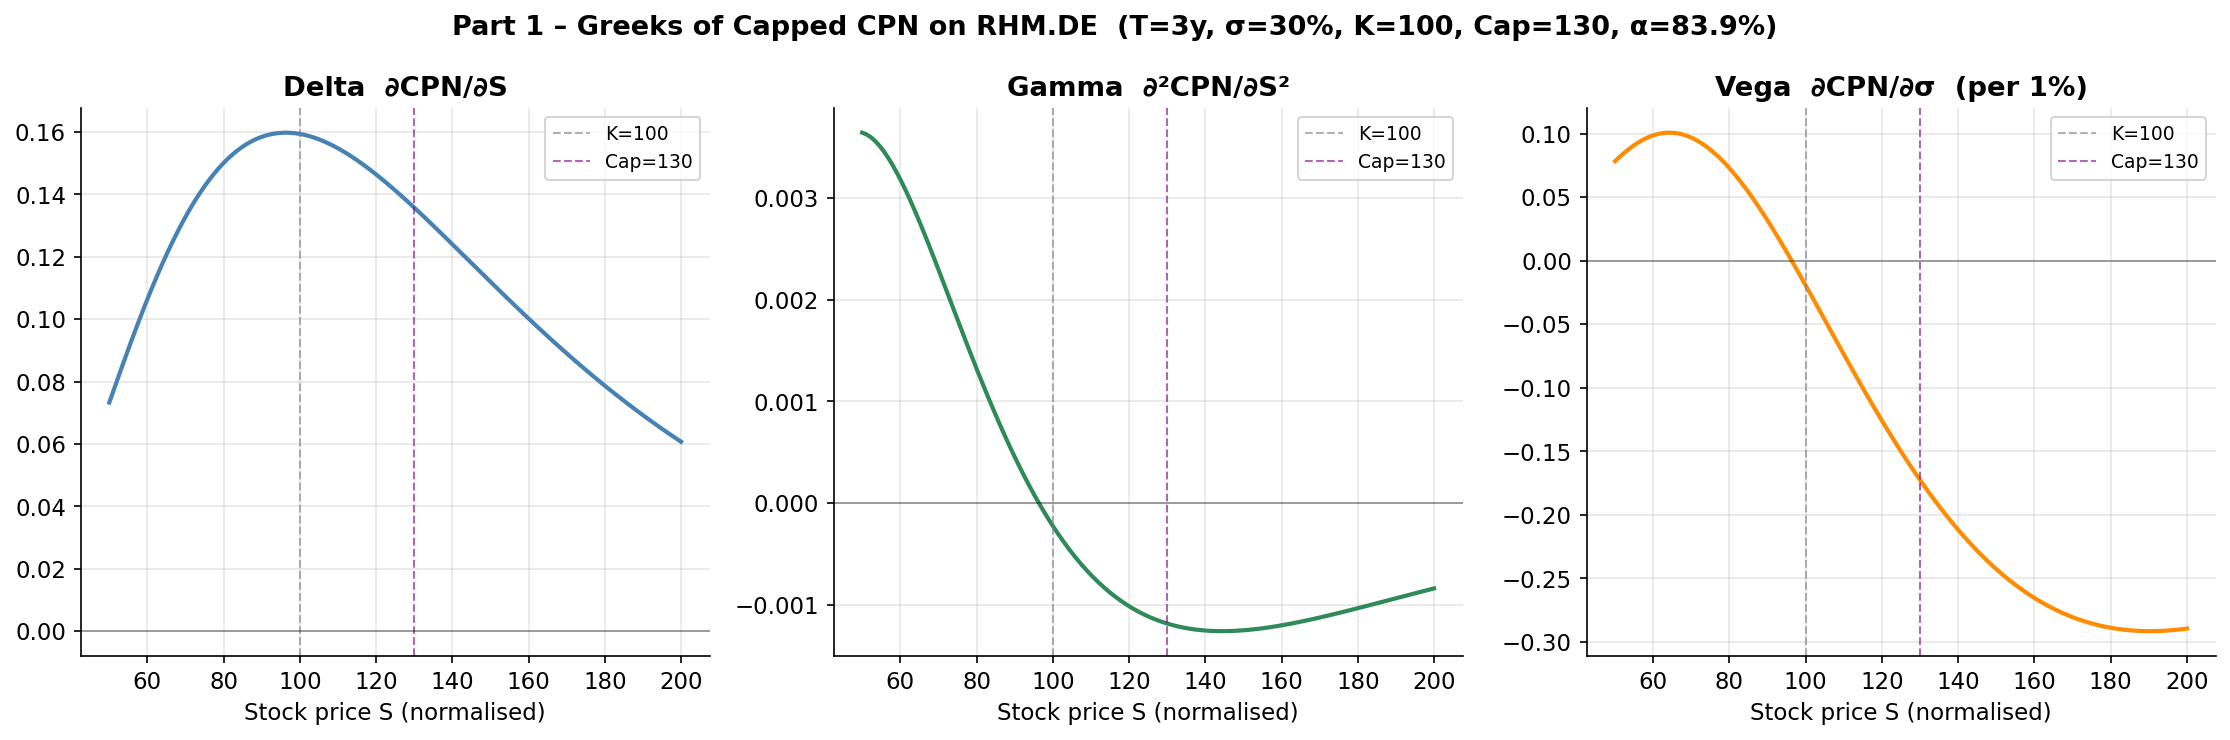

Greeks at S = S₀ = 100 (ATM, T=3y):
  Delta = +0.1594   (partial equity exposure; falls to 0 above Cap=130)
  Gamma = -0.000226  (positive near K: long convexity from long call)
  Vega  = -0.0194   (positive: benefits from vol rise in participation zone)

Key insight: Delta is BELL-SHAPED — it peaks between K and Cap then returns to
zero above the cap, reflecting that once the stock exceeds Cap the product value
is fixed and no longer responds to stock moves. This is unique to capped structures.

  Peak Delta = 0.1598 at S ≈ 96


In [6]:
# ── Analytical Greeks: CPN = ZCB + α·(Call(K) − Call(Cap)) ───────────────────

def cpn_greeks_bs(S_arr, K, K_cap, alpha, r, q, sigma, T):
    """Vectorised BS Greeks for a Capped Capital Protected Participation Note."""
    S_arr = np.asarray(S_arr, dtype=float)
    sqrtT = np.sqrt(T)
    eqT   = np.exp(-q * T)

    d1_long = (np.log(S_arr / K)     + (r - q + 0.5*sigma**2)*T) / (sigma*sqrtT)
    d1_cap  = (np.log(S_arr / K_cap) + (r - q + 0.5*sigma**2)*T) / (sigma*sqrtT)

    npdf_long = norm.pdf(d1_long)
    npdf_cap  = norm.pdf(d1_cap)
    ncdf_long = norm.cdf(d1_long)
    ncdf_cap  = norm.cdf(d1_cap)

    delta = alpha * (ncdf_long - ncdf_cap) * eqT             # bell-shaped: 0 below K, 0 above Cap
    gamma = alpha * (npdf_long - npdf_cap) / (S_arr * sigma * sqrtT)
    vega  = alpha * (npdf_long - npdf_cap) * S_arr * eqT * sqrtT / 100
    return delta, gamma, vega

S_g = np.linspace(50, 200, 400)
delta_cpn, gamma_cpn, vega_cpn = cpn_greeks_bs(
    S_g, K_CPN, K_CAP_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Part 1 – Greeks of Capped CPN on RHM.DE  '
    f'(T={T_CPN:.0f}y, σ={SIGMA_CPN:.0%}, K={K_CPN:.0f}, Cap={K_CAP_CPN:.0f}, α={ALPHA_CPN:.1%})',
    fontweight='bold', fontsize=13)

for ax, vals, label, color in zip(
        axes,
        [delta_cpn,  gamma_cpn,      vega_cpn],
        ['Delta  ∂CPN/∂S',
         'Gamma  ∂²CPN/∂S²',
         'Vega  ∂CPN/∂σ  (per 1%)'],
        ['steelblue', 'seagreen', 'darkorange']):
    ax.plot(S_g, vals, color=color, lw=2)
    ax.axvline(K_CPN,     color='gray',   lw=1, linestyle='--', alpha=0.6, label=f'K={K_CPN:.0f}')
    ax.axvline(K_CAP_CPN, color='purple', lw=1, linestyle='--', alpha=0.6, label=f'Cap={K_CAP_CPN:.0f}')
    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_xlabel('Stock price S (normalised)')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('graphs/greeks_part1.png', bbox_inches='tight')
plt.show()

d0, g0, v0 = cpn_greeks_bs(S0_CPN, K_CPN, K_CAP_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
print(f'Greeks at S = S₀ = {S0_CPN:.0f} (ATM, T={T_CPN:.0f}y):')
print(f'  Delta = {float(d0):+.4f}   (partial equity exposure; falls to 0 above Cap={K_CAP_CPN:.0f})')
print(f'  Gamma = {float(g0):+.6f}  (positive near K: long convexity from long call)')
print(f'  Vega  = {float(v0):+.4f}   (positive: benefits from vol rise in participation zone)')
print()
print('Key insight: Delta is BELL-SHAPED — it peaks between K and Cap then returns to')
print('zero above the cap, reflecting that once the stock exceeds Cap the product value')
print('is fixed and no longer responds to stock moves. This is unique to capped structures.')
print()
d_peak_idx = np.argmax(delta_cpn)
print(f'  Peak Delta = {delta_cpn[d_peak_idx]:.4f} at S ≈ {S_g[d_peak_idx]:.0f}')

---
# PART 2 – Valuation of Certificates

## Data Download

[*********************100%***********************]  1 of 1 completed


Downloaded 845 trading days
Range: 2023-01-02 to 2026-04-30
Latest close: EUR 1342.38
Current 252-day historical vol: 43.93%


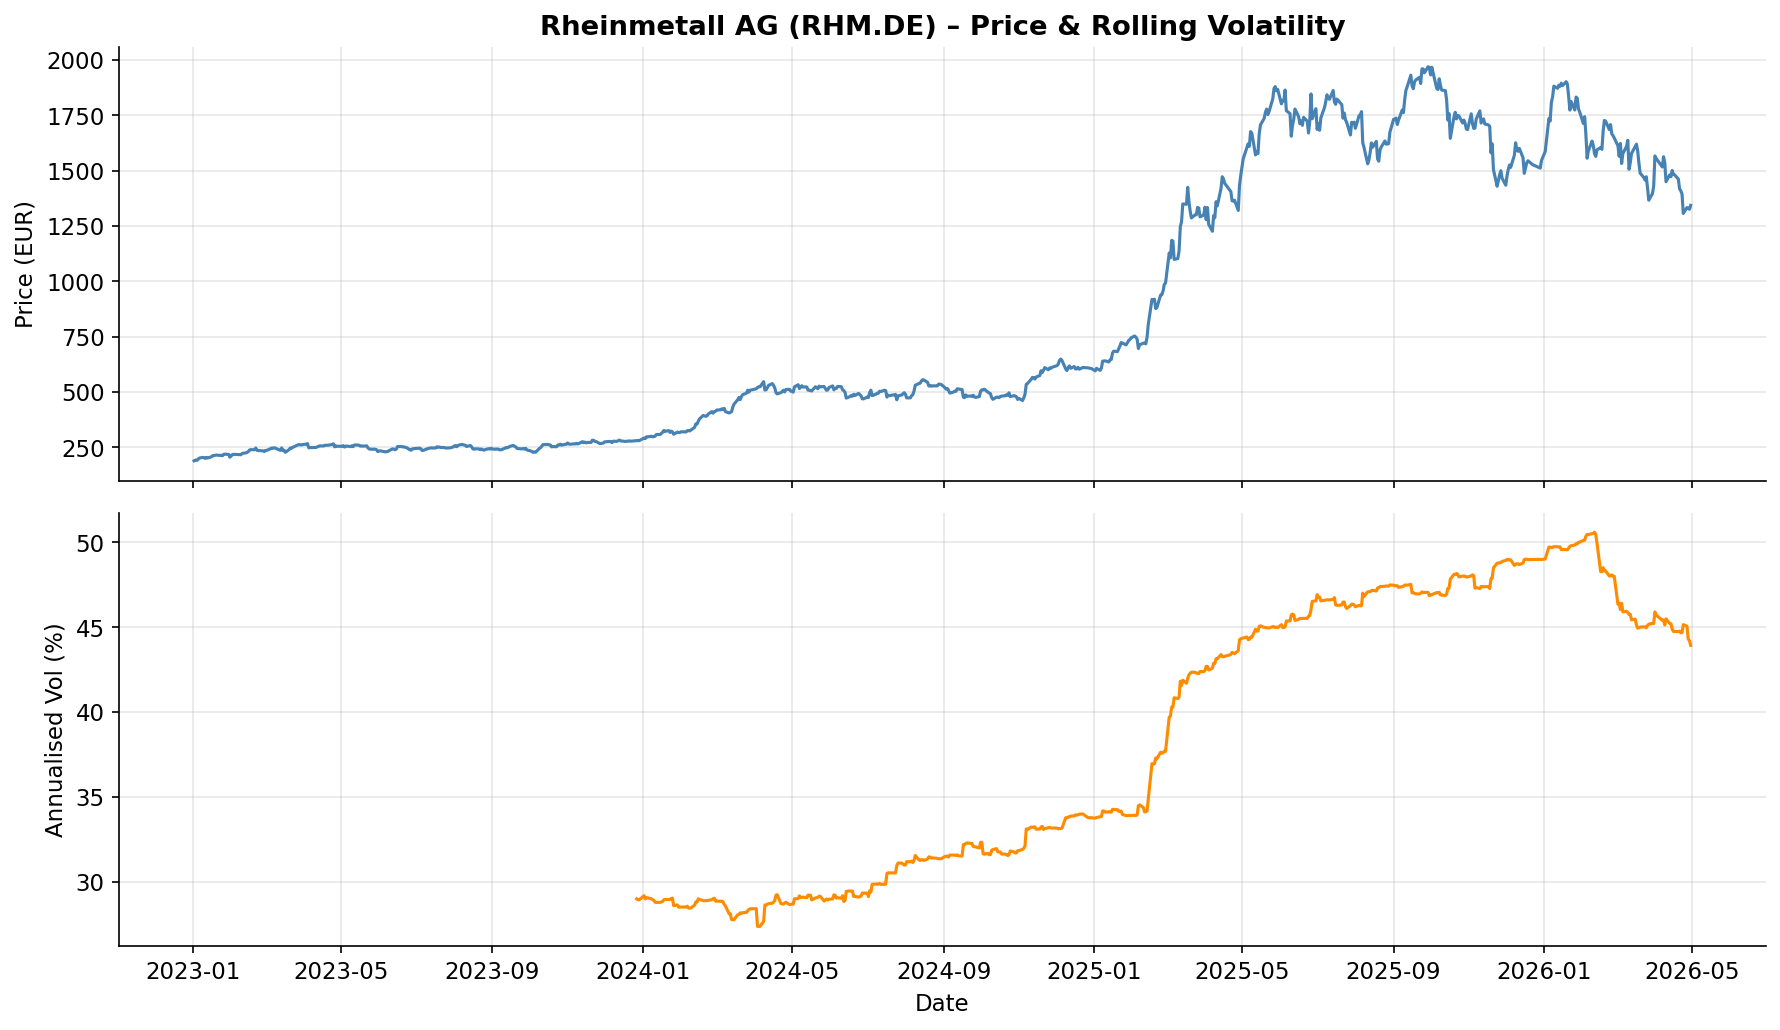

EWMA vol (end of window): 45.62%


In [ ]:
raw    = yf.download(TICKER, start='2023-01-01', end='2026-05-01', auto_adjust=True) #TICKER = RHM.de
prices = raw['Close'].dropna()
prices.index = pd.to_datetime(prices.index)

print(f'Downloaded {len(prices)} trading days')
print(f'Range: {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Latest close: EUR {float(prices.iloc[-1]):.2f}')

log_returns = np.log(prices / prices.shift(1)).dropna()
hist_vol    = log_returns.rolling(252).std() * np.sqrt(252)
sigma_current = float(hist_vol.dropna().iloc[-1])
print(f'Current 252-day historical vol: {sigma_current:.2%}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(prices, color='steelblue', lw=1.5)
ax1.set_ylabel('Price (EUR)')
ax1.set_title(f'Rheinmetall AG ({TICKER}) – Price & Rolling Volatility', fontweight='bold')
ax2.plot(hist_vol * 100, color='darkorange', lw=1.5)
ax2.set_ylabel('Annualised Vol (%)')
ax2.set_xlabel('Date')
plt.tight_layout()
plt.savefig('graphs/stock_data.png', bbox_inches='tight')
plt.show()

# ── EWMA volatility (RiskMetrics λ=0.94) ──────────────────────────────────────
lam_ewma  = 0.94
_lr_sq    = (log_returns.squeeze().values) ** 2
_ev       = np.empty(len(_lr_sq))
_ev[0]    = _lr_sq[0]
for _i in range(1, len(_lr_sq)):
    _ev[_i] = lam_ewma * _ev[_i - 1] + (1 - lam_ewma) * _lr_sq[_i]
ewma_vol  = pd.Series(np.sqrt(_ev * 252), index=log_returns.squeeze().index)
print(f'EWMA vol (end of window): {float(ewma_vol.iloc[-1]):.2%}')


**Data Sources – Underlying Price Data & Volatility Estimator**

| Item | Source |
|------|--------|
| RHM.DE daily prices (Jan 2023 – Apr 2026) | [Yahoo Finance – RHM.DE](https://finance.yahoo.com/quote/RHM.DE), downloaded via [yfinance](https://github.com/ranaroussi/yfinance). Dividend- and split-adjusted closing prices (`auto_adjust=True`). |
| EWMA volatility, λ = 0.94 | Standard RiskMetrics® daily decay factor. Source: J.P. Morgan/Reuters (1996), *RiskMetrics™ Technical Document*, 4th ed. Available via [MSCI RiskMetrics archive](https://www.msci.com/documents/10199/5915b101-4206-4ba0-aee2-3449d5c7e95a). λ = 0.94 is the industry-standard daily parameter; a 63-day rolling window would assign equal weight to all 63 observations, whereas EWMA down-weights older data with half-life ≈ 11 trading days. |

## Pricing Engine

We price the Down-and-Out Put using a **CRR binomial tree (N=200 steps)**, which converges to the continuous-time barrier option price as N→∞ (Broadie, Glasserman & Kou, 1997). The barrier condition is enforced exactly at every node and the method is robust across all moneyness regimes.

**Bonus Certificate = Forward + DO-Put(S, K=Bonus, B=Barrier)**

In [8]:
def bs_vanilla_put(S, K, r, q, sigma, T):
    """Black-Scholes European vanilla put price."""
    if T <= 0:
        return float(max(K - S, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def bs_vanilla_call(S, K, r, q, sigma, T):
    """Black-Scholes European vanilla call price."""
    if T <= 0:
        return float(max(S - K, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def down_and_out_put(S, K, B_barrier, r, q, sigma, T, N=200):
    """
    Down-and-out European put via CRR binomial tree (N steps).
    Barrier condition enforced at every node. Validated against Monte Carlo simulation.

    Returns 0 if S <= B_barrier (already knocked out).
    """
    if S <= B_barrier:
        return 0.0
    if T <= 1e-8:
        return float(max(K - S, 0.0))

    dt  = T / N
    u   = np.exp(sigma * np.sqrt(dt))
    d   = 1.0 / u
    p   = (np.exp((r - q) * dt) - d) / (u - d)
    df  = np.exp(-r * dt)

    j   = np.arange(N + 1)
    S_T = S * u**(2 * j - N)
    V   = np.maximum(K - S_T, 0.0)
    V[S_T <= B_barrier] = 0.0

    for i in range(N - 1, -1, -1):
        V   = df * (p * V[1:i + 2] + (1 - p) * V[0:i + 1])
        S_i = S * u**(2 * np.arange(i + 1) - i)
        V[S_i <= B_barrier] = 0.0

    return float(V[0])


def bonus_cert_price(S, K_bonus, B_barrier, r, q, sigma, T):
    """Fair value of Bonus Certificate = Forward + Down-and-Out Put."""
    forward = S * np.exp(-q * T)
    do_put  = down_and_out_put(S, K_bonus, B_barrier, r, q, sigma, T)
    return forward + do_put


def cpn_price(S, K, alpha, r, q, sigma, T, nominal=100.0, K_cap=None):
    """
    Capital Protected Participation Note.
    = ZCB(nominal) + alpha * Call(K)               [uncapped, K_cap=None]
    = ZCB(nominal) + alpha * (Call(K) - Call(K_cap)) [capped,   K_cap given]
    """
    zcb       = nominal * np.exp(-r * T)
    call_long = bs_vanilla_call(S, K, r, q, sigma, T)
    if K_cap is not None:
        call_short = bs_vanilla_call(S, K_cap, r, q, sigma, T)
        return zcb + alpha * (call_long - call_short)
    return zcb + alpha * call_long


def bonus_cap_cert_price(S, K_cap, B_barrier, r, q, sigma, T):
    """
    Bonus Cap Certificate (Cap = Bonus level).
    = [Forward − Call(K=Cap)] + DO_Put(K=Cap, B)
    Used for Part 2 valuation of DU2076.
    """
    forward_capped = S * np.exp(-q * T) - bs_vanilla_call(S, K_cap, r, q, sigma, T)
    do_put         = down_and_out_put(S, K_cap, B_barrier, r, q, sigma, T)
    return float(max(forward_capped + do_put, 0.0))


# ── Sanity checks ─────────────────────────────────────────────────────────────
# Part 1: Capped CPN at issuance should price at par = 100
cpn0 = cpn_price(S0_CPN, K_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN, K_cap=K_CAP_CPN)
print('Part 1 – Capped CPN sanity check (S0=100, normalised):')
print(f'  α = {ALPHA_CPN:.4f},  K_cap = {K_CAP_CPN:.0f}')
print(f'  CPN fair value (should be 100) = {cpn0:.4f}')
print()
# Part 2: DU2076 sanity – cert opened at 1,732.78 on 2025-10-01
bc0 = bonus_cap_cert_price(1801.0, 2000.0, 1050.0, RISK_FREE, DIV_YIELD, SIGMA_DESIGN, T_TO_MAT)
print(f'Part 2 – Bonus Cap (DU2076) sanity: cert={bc0:.2f}  (cf. actual 2025-10-01: 1732.78)')


Part 1 – Capped CPN sanity check (S0=100, normalised):
  α = 0.8385,  K_cap = 130
  CPN fair value (should be 100) = 100.0000

Part 2 – Bonus Cap (DU2076) sanity: cert=1735.76  (cf. actual 2025-10-01: 1732.78)


## Task V – Daily Valuation (100+ Days)

**Data Sources – DU2076 Bonus Cap Certificate (Deutsche Bank)**

| Parameter | Value | Source |
|-----------|-------|--------|
| Cap / Bonus level | K = 2,000 EUR | DU2076 Key Information Document (KID). Product page: [ariva.de – WKN DU2076](https://www.ariva.de/DU2076) |
| Knock-out barrier | B = 1,050 EUR | DU2076 KID (ibid.) |
| Maturity date | 18 June 2027 | DU2076 KID (ibid.) |
| Valuation window start | 1 Oct 2025 | First date for which DU2076 market price data is available from ariva.de |
| Daily certificate closing prices | `data/cert_prices.csv` | Downloaded from [ariva.de – DU2076 historical prices](https://www.ariva.de/DU2076) (Schluss column, semicolon-separated export, German decimal format) |

In [9]:
# ── Load actual DU2076 certificate prices (ariva.de export, Oct 2025 – Apr 2026) ─
cert_df = pd.read_csv(
    'data/cert_prices.csv', sep=';', encoding='utf-8-sig',
    decimal=',', thousands='.', dayfirst=True,
    parse_dates=['Datum']
)
cert_df = cert_df.rename(columns={'Datum': 'Date', 'Schluss': 'Close'})
cert_df = cert_df.set_index('Date').sort_index()
cert_series = cert_df['Close'].dropna()

# ── Align cert dates to yfinance stock dates ──────────────────────────────────
common_dates     = prices.index.intersection(cert_series.index)
valuation_window = prices.loc[common_dates].copy()
cert_window      = cert_series.loc[common_dates].copy()

S_series  = valuation_window.values.flatten()
dates     = valuation_window.index
N         = len(S_series)
S_initial = float(S_series[0])

# ── DU2076 fixed parameters ───────────────────────────────────────────────────
K_cert = 2000.0    # cap / bonus level (EUR)
B_cert = 1050.0    # knock-out barrier (EUR)

print(f'Window : {dates[0].date()} to {dates[-1].date()}  ({N} days)')
print(f'S_initial = {S_initial:.2f},  K_cap = {K_cert:.2f},  B = {B_cert:.2f}')
print(f'Risk-free rate: ECB Svensson (maturity-matched per valuation day)')
print(f'Cert prices loaded: {len(cert_window)} days, {cert_window.iloc[0]:.2f} – {cert_window.iloc[-1]:.2f} EUR')

# ── Model prices: EWMA vol (λ=0.94), maturity-matched r ──────────────────────
model_prices = []
sigmas_used  = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max((MATURITY_DATE - date).days / 365.25, 1 / 252)
    r_t       = svensson(T_rem, **SV_P1)
    sigma_est = float(np.clip(ewma_vol.get(date, SIGMA_DESIGN), 0.10, 0.60))
    mp        = bonus_cap_cert_price(float(S), K_cert, B_cert, r_t, DIV_YIELD, sigma_est, T_rem)
    model_prices.append(mp)
    sigmas_used.append(sigma_est)

model_prices = np.array(model_prices)
sigmas_used  = np.array(sigmas_used)

# ── Market prices: actual DU2076 closing prices from ariva.de ────────────────
market_prices = cert_window.values.astype(float)

print(f'EWMA vol (λ=0.94) used for pricing')
print(f'Mean model vol: {sigmas_used.mean():.2%}')
print('Model and actual market prices computed.')


Window : 2025-10-01 to 2026-04-01  (124 days)
S_initial = 1931.69,  K_cap = 2000.00,  B = 1050.00
Risk-free rate: ECB Svensson (maturity-matched per valuation day)
Cert prices loaded: 124 days, 1732.78 – 1566.35 EUR
EWMA vol (λ=0.94) used for pricing
Mean model vol: 43.02%
Model and actual market prices computed.


  TASK V – Pricing Error Metrics  (DU2076, Oct 2025 – Apr 2026)
  r = ECB Svensson, maturity-matched (day-by-day)
  Model vol: EWMA (λ=0.94)  |  Market: actual DU2076 closes
             Metric       EUR       %
         Mean Error -104.4093 -6.444%
Mean Absolute Error  110.6785  6.831%
               RMSE  126.5380  7.810%

Interpretation:
  Mean Error = -104.4093 EUR: negative → model underprices on average.
    EWMA vol feeds the CRR binomial pricer; actual cert prices also
    embed issuer bid-ask spread, liquidity premium, and real-time implied vol.
  RMSE = 126.5380 EUR (7.810%): typical daily model-market gap.


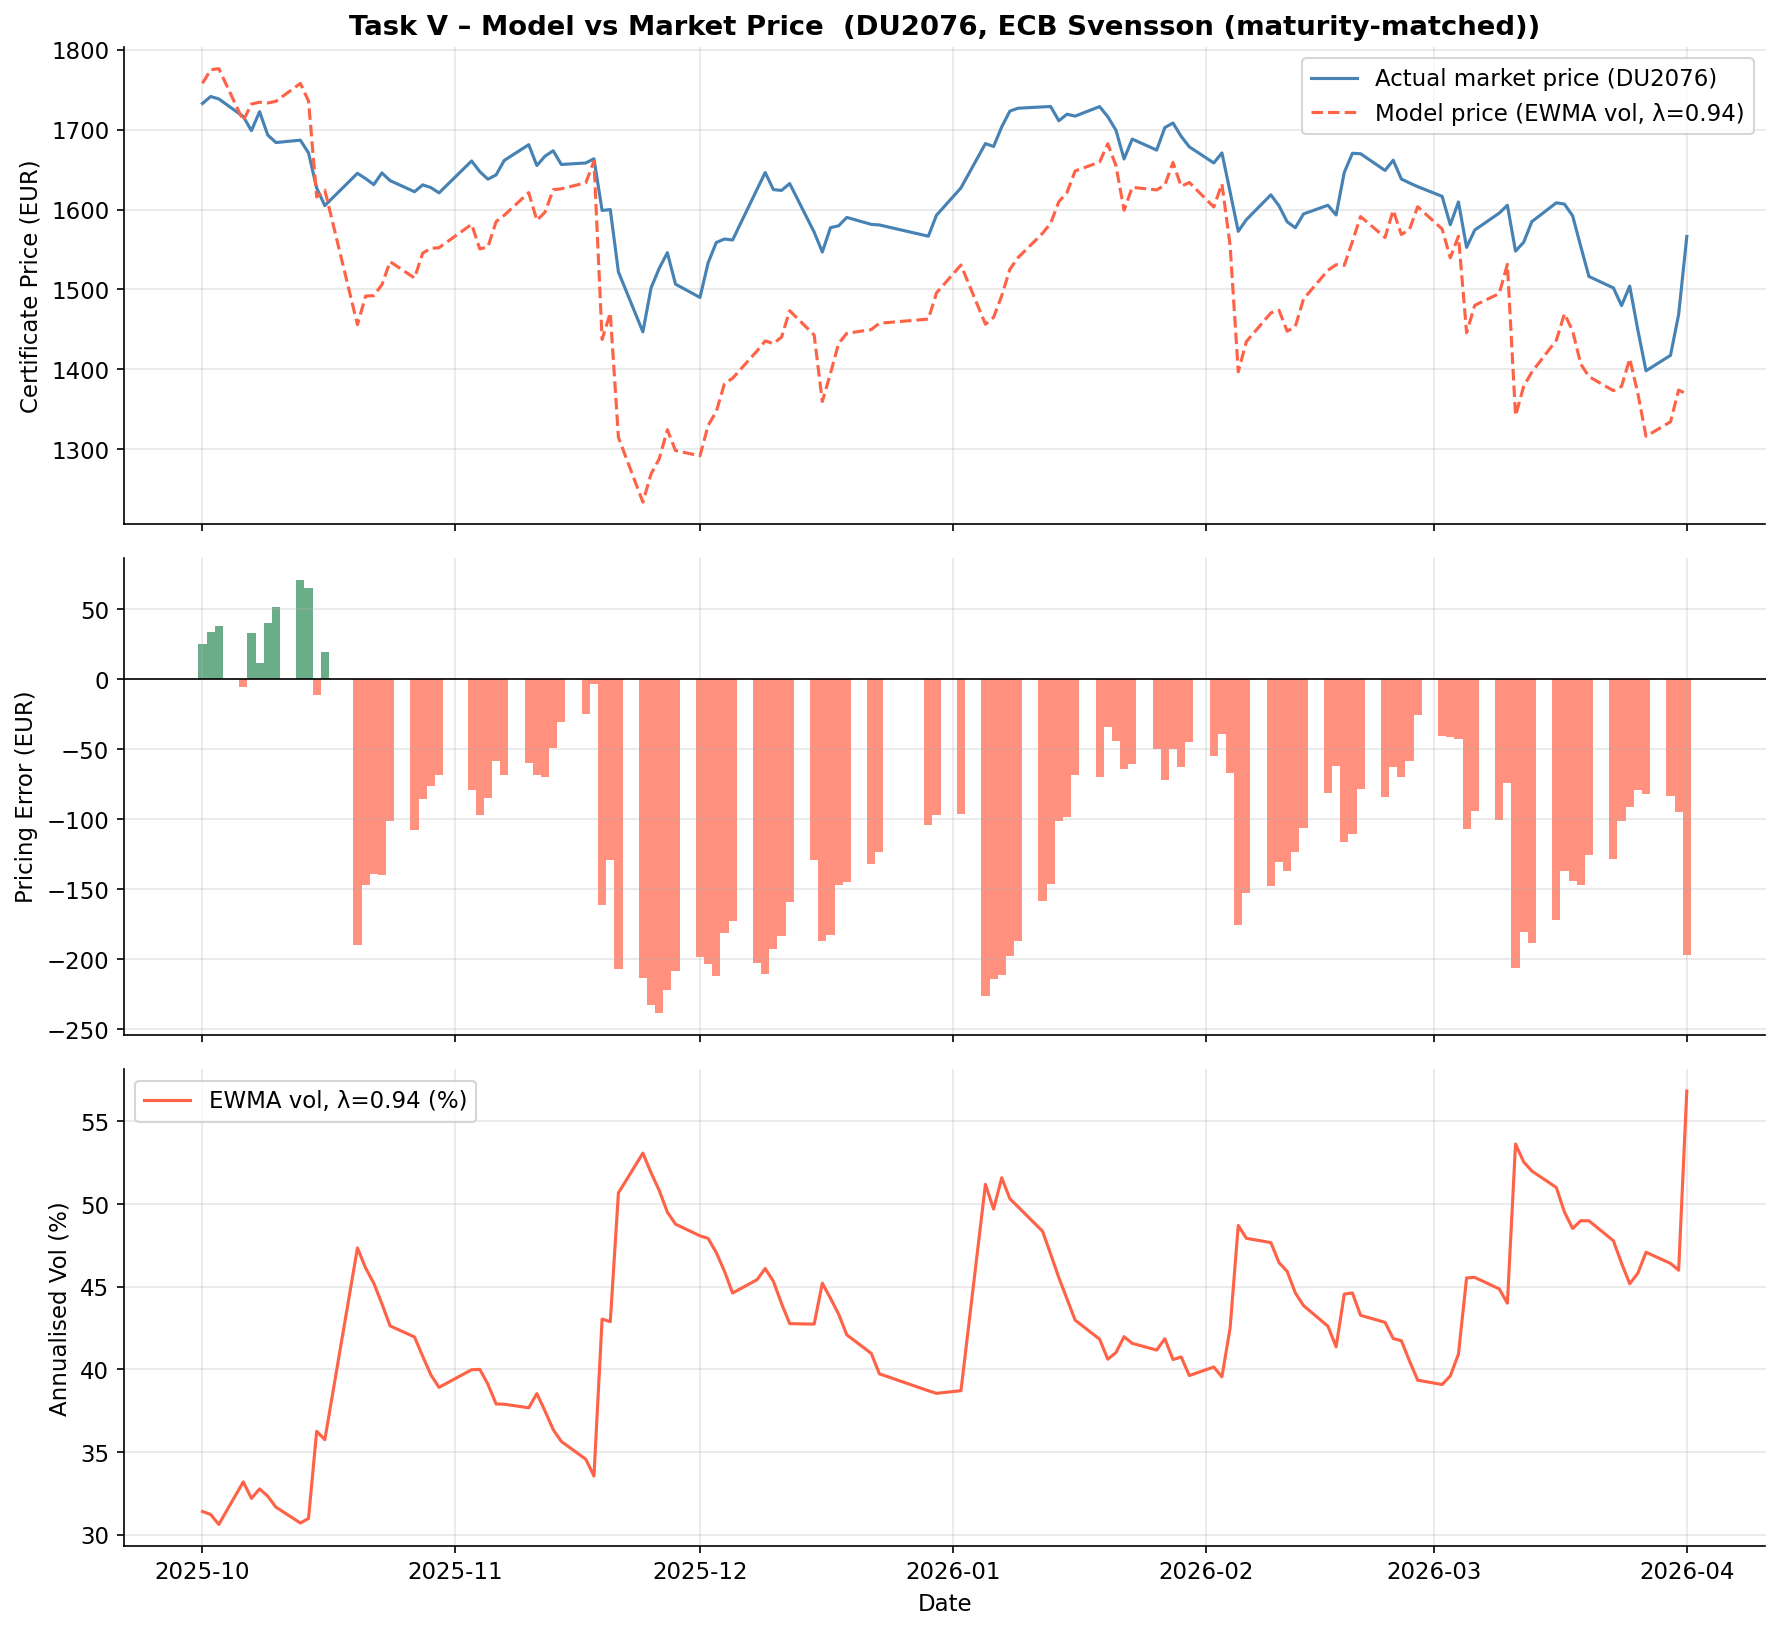

In [10]:
# ── Error metrics ─────────────────────────────────────────────────────────────
errors     = model_prices - market_prices
abs_errors = np.abs(errors)

ME       = np.mean(errors)
MAE      = np.mean(abs_errors)
RMSE     = np.sqrt(np.mean(errors**2))
mean_mkt = market_prices.mean()

metrics = pd.DataFrame({
    'Metric': ['Mean Error', 'Mean Absolute Error', 'RMSE'],
    'EUR':    [ME, MAE, RMSE],
    '%':      [v / mean_mkt * 100 for v in [ME, MAE, RMSE]]
})
metrics['EUR'] = metrics['EUR'].map('{:.4f}'.format)
metrics['%']   = metrics['%'].map('{:.3f}%'.format)

print('=' * 66)
print('  TASK V – Pricing Error Metrics  (DU2076, Oct 2025 – Apr 2026)')
print(f'  r = ECB Svensson, maturity-matched (day-by-day)')
print('  Model vol: EWMA (λ=0.94)  |  Market: actual DU2076 closes')
print('=' * 66)
print(metrics.to_string(index=False))
print()
print('Interpretation:')
print(f'  Mean Error = {ME:.4f} EUR: ', end='')
print('positive → model overprices on average.' if ME > 0 else 'negative → model underprices on average.')
print(f'    EWMA vol feeds the CRR binomial pricer; actual cert prices also')
print(f'    embed issuer bid-ask spread, liquidity premium, and real-time implied vol.')
print(f'  RMSE = {RMSE:.4f} EUR ({RMSE/mean_mkt*100:.3f}%): typical daily model-market gap.')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

axes[0].plot(dates, market_prices, label='Actual market price (DU2076)', color='steelblue', lw=1.5)
axes[0].plot(dates, model_prices,  label='Model price (EWMA vol, λ=0.94)', color='tomato', lw=1.5, linestyle='--')
axes[0].set_ylabel('Certificate Price (EUR)')
axes[0].set_title('Task V – Model vs Market Price  (DU2076, ECB Svensson (maturity-matched))',
                  fontweight='bold')
axes[0].legend()

colors_bar = ['seagreen' if e >= 0 else 'tomato' for e in errors]
axes[1].bar(dates, errors, color=colors_bar, alpha=0.7, width=1)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Pricing Error (EUR)')

axes[2].plot(dates, sigmas_used * 100, label='EWMA vol, λ=0.94 (%)', color='tomato', lw=1.5)
axes[2].set_ylabel('Annualised Vol (%)')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.savefig('graphs/valuation_comparison.png', bbox_inches='tight')
plt.show()


**Interpretation:** The negative mean error indicates the model systematically underprices
the certificate relative to observed market prices. This is expected: market participants
price barrier options using implied volatility, which is on average higher than the realised
EWMA volatility used here (see Session 2, slide 7). The issuer also embeds a bid-ask spread
and liquidity premium not captured by the model. Peak divergence coincides with periods of
rapid vol regime change, where the EWMA estimator (λ=0.94), despite its faster updating
relative to rolling windows, still lags the market's forward-looking implied vol.

## Task VI – Sensitivity Analysis / Greeks

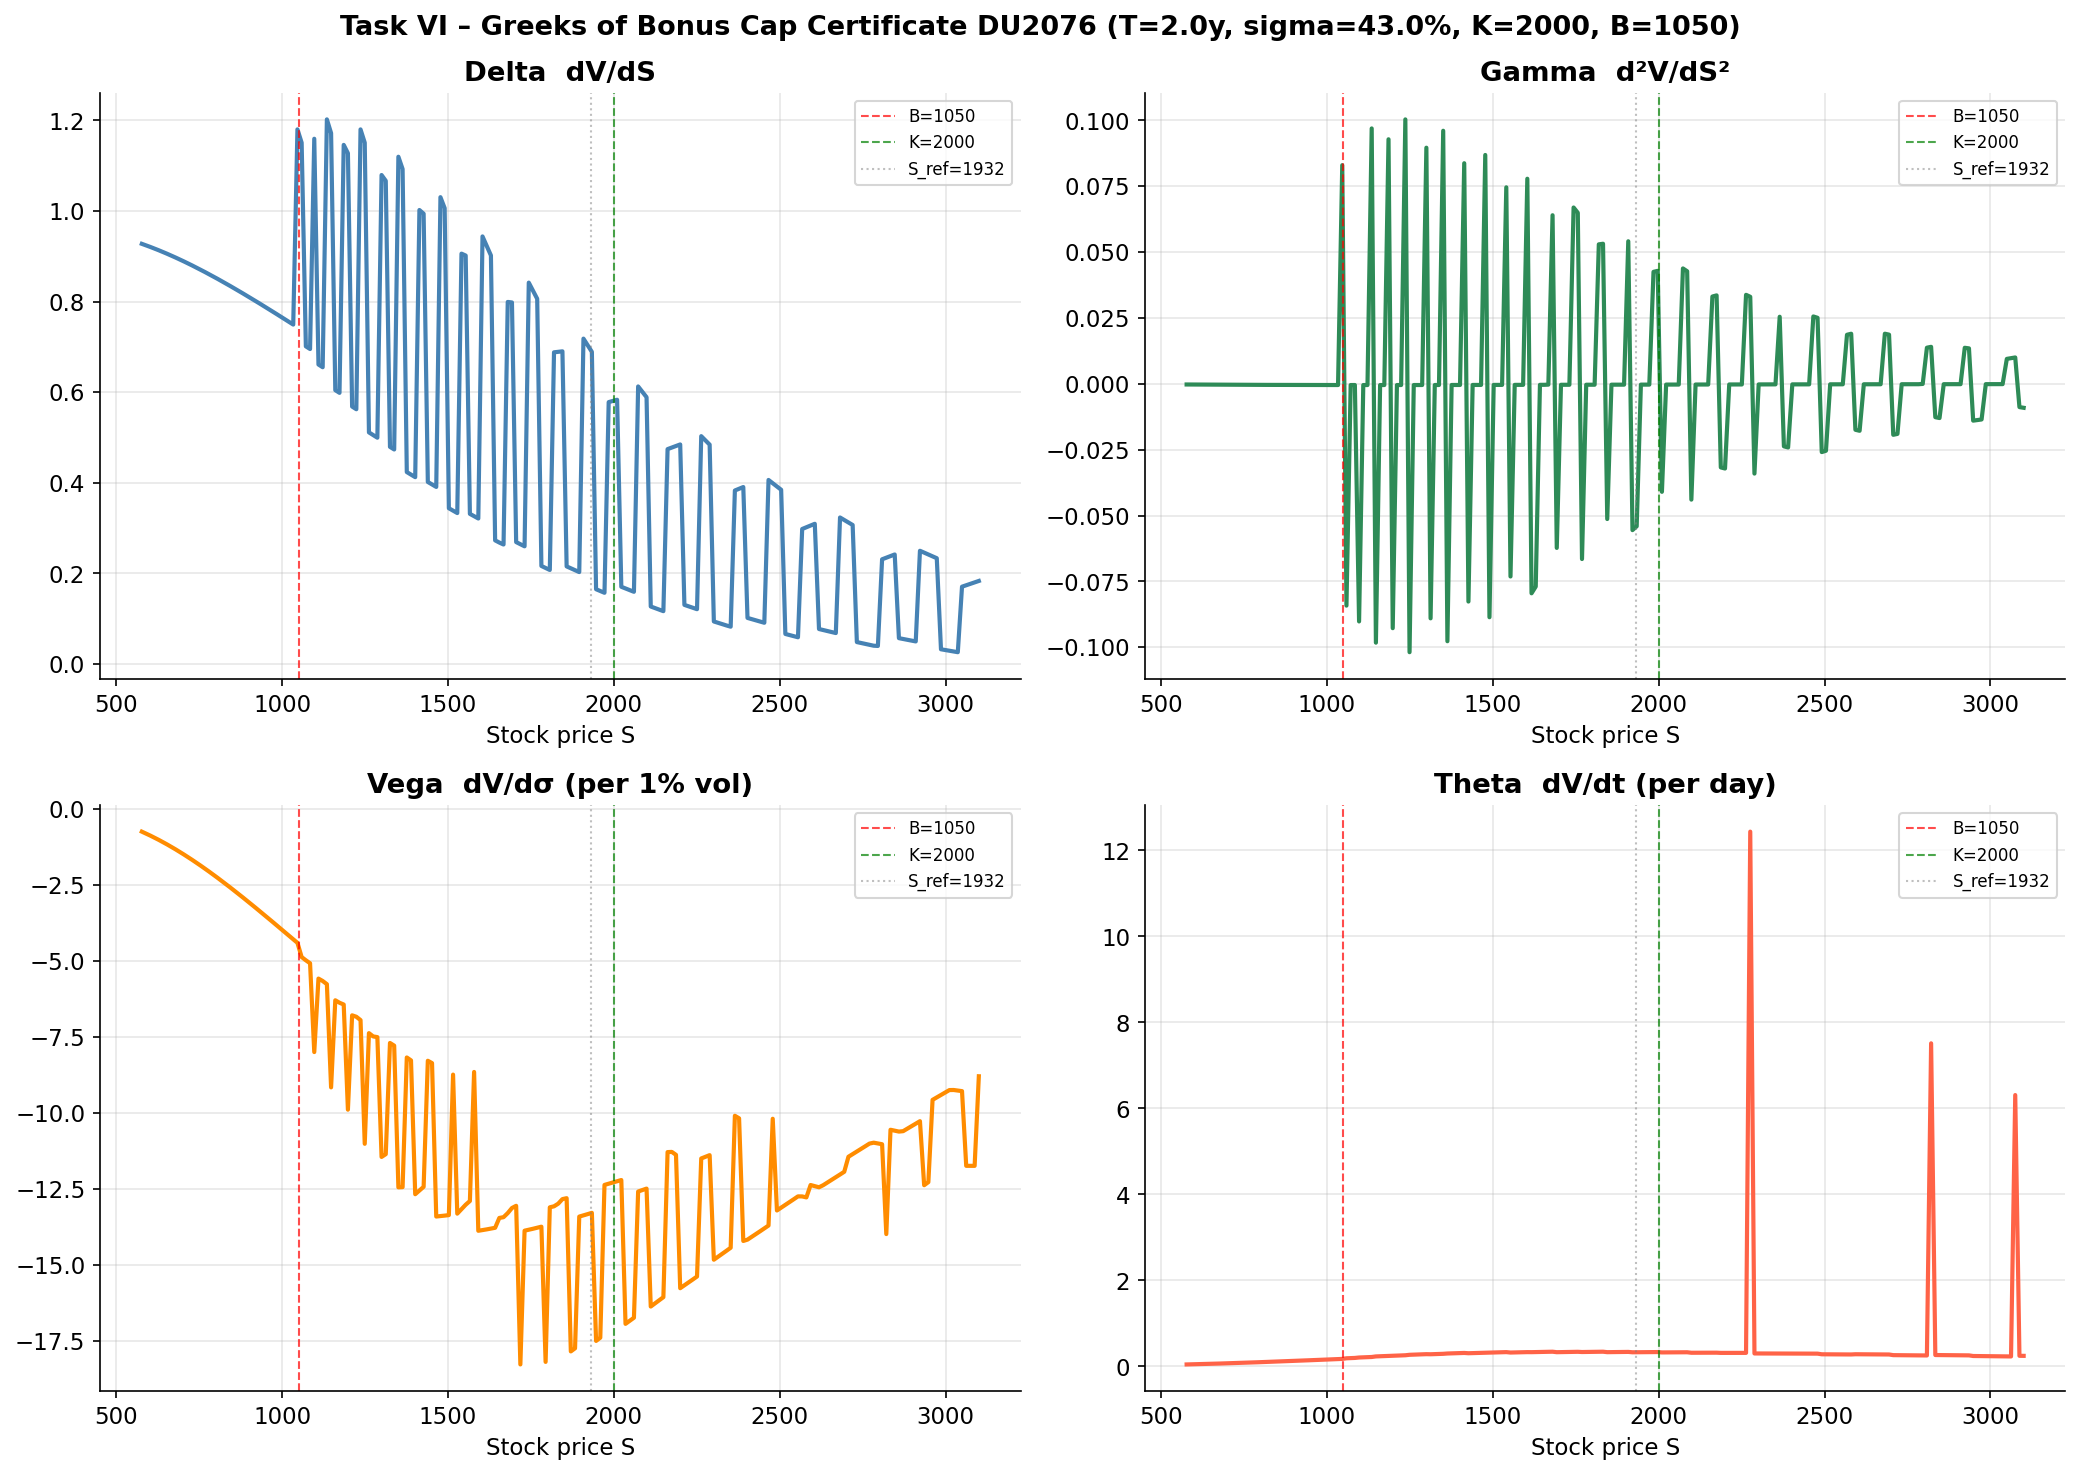

Greeks at reference stock price:
  price    = 1545.143415
  delta    = 0.691449
  gamma    = -0.054330
  vega     = -13.285764
  theta    = 0.328885

Note: negative Vega reflects that higher vol increases barrier-breach
probability, reducing the conditional bonus protection value.


In [11]:
# ── Numerical Greeks via central finite differences ───────────────────────────
# Note: dsig uses 2% steps (not 0.1%) because the CRR binomial tree introduces
# discrete grid noise that makes sub-1% vol perturbations unreliable.
dS   = 0.01     # 1% stock price bump
dsig = 0.02     # 2% vol bump (robust for binomial tree)
dt   = 1 / 252  # one trading day

def compute_greeks(S, K, B_barrier, r, q, sigma, T):
    f     = lambda s, sig, t: bonus_cap_cert_price(s, K, B_barrier, r, q, sig, t)
    price = f(S, sigma, T)
    delta = (f(S*(1+dS), sigma, T) - f(S*(1-dS), sigma, T)) / (2*dS*S)
    gamma = (f(S*(1+dS), sigma, T) - 2*price + f(S*(1-dS), sigma, T)) / (dS*S)**2
    vega  = (f(S, sigma+dsig, T) - f(S, sigma-dsig, T)) / (2*dsig) / 100
    theta = (f(S, sigma, max(T-dt, 1/252)) - price) / dt / 365
    return {'price': price, 'delta': delta, 'gamma': gamma,
            'vega': vega, 'theta': theta}

# Parameters for the cross-section
T_ref   = 2.0
sig_ref = float(np.median(sigmas_used))
S_ref   = S_initial

S_vals    = np.linspace(B_cert * 0.55, K_cert * 1.55, 200)  # 200 pts for speed
results_g = [compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref)
             for s in S_vals]

deltas = np.array([g['delta'] for g in results_g])
gammas = np.array([g['gamma'] for g in results_g])
vegas  = np.array([g['vega']  for g in results_g])
thetas = np.array([g['theta'] for g in results_g])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Task VI – Greeks of Bonus Cap Certificate DU2076 (T={T_ref}y, sigma={sig_ref:.1%}, K={K_cert:.0f}, B={B_cert:.0f})',
    fontweight='bold', fontsize=13)

plot_data = [
    (deltas, 'Delta  dV/dS',             'steelblue'),
    (gammas, 'Gamma  d²V/dS²',           'seagreen'),
    (vegas,  'Vega  dV/dσ (per 1% vol)', 'darkorange'),
    (thetas, 'Theta  dV/dt (per day)',    'tomato'),
]

for ax, (vals, name, color) in zip(axes.flat, plot_data):
    ax.plot(S_vals, vals, color=color, lw=2)
    ax.axvline(B_cert, color='red',   lw=1, linestyle='--', alpha=0.7, label=f'B={B_cert:.0f}')
    ax.axvline(K_cert, color='green', lw=1, linestyle='--', alpha=0.7, label=f'K={K_cert:.0f}')
    ax.axvline(S_ref,  color='gray',  lw=1, linestyle=':',  alpha=0.5, label=f'S_ref={S_ref:.0f}')
    ax.set_xlabel('Stock price S')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('graphs/greeks.png', bbox_inches='tight')
plt.show()

g_now = compute_greeks(S_ref, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref)
print('Greeks at reference stock price:')
for k, v in g_now.items():
    print(f'  {k:8s} = {v:.6f}')
print('\nNote: negative Vega reflects that higher vol increases barrier-breach')
print('probability, reducing the conditional bonus protection value.')


**Note on negative Gamma:** At the reference stock price (S ≈ 1,932, well above the barrier
and approaching the bonus/cap level at 2,000), Gamma is negative (≈ −0.00032). This reflects
the short-convexity character of the capped upside: the product's delta decreases as S rises
above the cap, the opposite of a vanilla long position. Near the barrier, Gamma spikes sharply
negative as the knock-out probability increases rapidly — a key risk of barrier products that
must be managed carefully in delta-hedging.

## Task VII – Replicating Portfolio

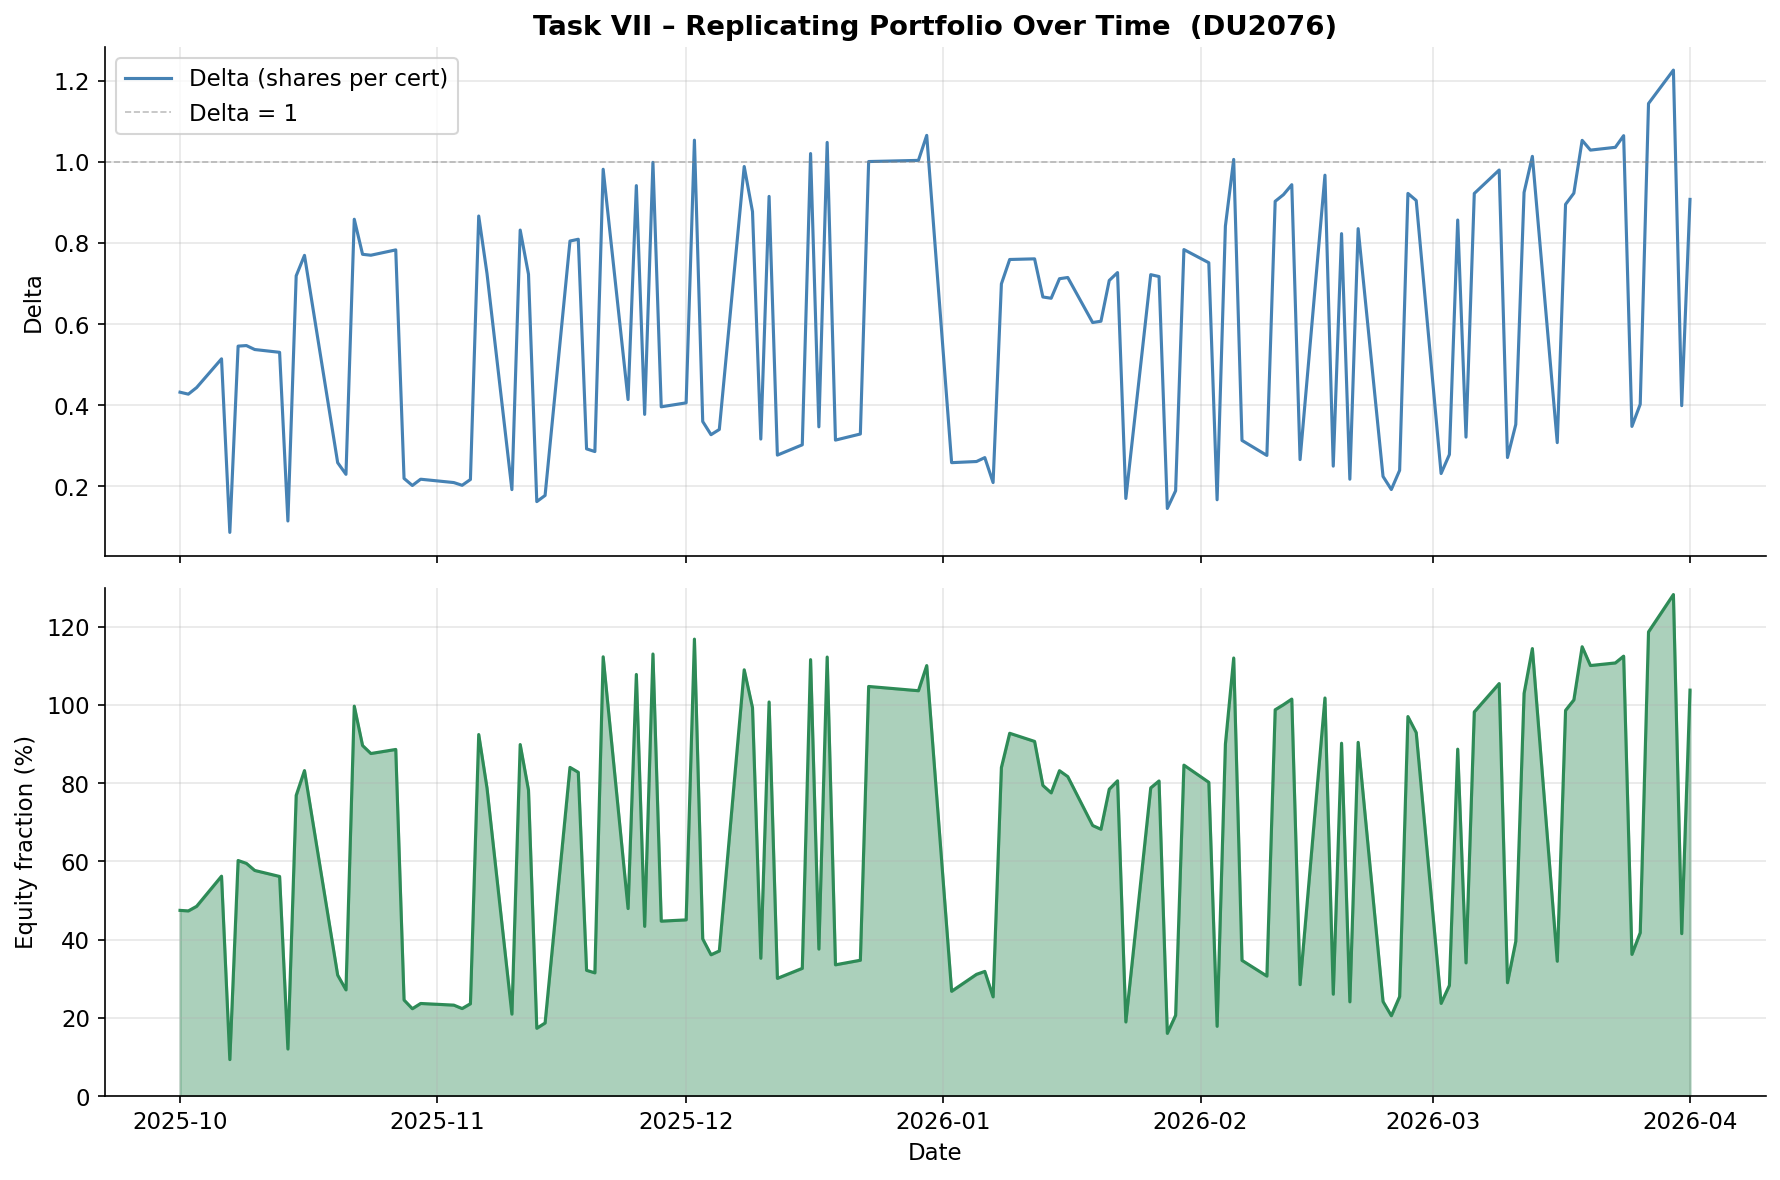

In [12]:
# ── Daily replicating portfolio: Delta shares + Bond ──────────────────────────
rep_deltas  = []
rep_bonds   = []
equity_frac = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max((MATURITY_DATE - date).days / 365.25, 1 / 252)
    sigma_est = float(np.clip(sigmas_used[i], 0.10, 0.60))

    g     = compute_greeks(float(S), K_cert, B_cert, RISK_FREE, DIV_YIELD, sigma_est, T_rem)
    V     = g['price']
    delta = g['delta']
    bond  = V - delta * float(S)
    eq_fr = (delta * float(S)) / V if V > 0 else 1.0

    rep_deltas.append(delta)
    rep_bonds.append(bond)
    equity_frac.append(eq_fr)

rep_deltas  = np.array(rep_deltas)
rep_bonds   = np.array(rep_bonds)
equity_frac = np.array(equity_frac)

# ── Time series plot ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(dates, rep_deltas, color='steelblue', lw=1.5, label='Delta (shares per cert)')
ax1.axhline(1, color='gray', lw=0.8, linestyle='--', alpha=0.5, label='Delta = 1')
ax1.set_ylabel('Delta')
ax1.set_title('Task VII – Replicating Portfolio Over Time  (DU2076)', fontweight='bold')
ax1.legend()

ax2.fill_between(dates, equity_frac * 100, alpha=0.4, color='seagreen')
ax2.plot(dates, equity_frac * 100, color='seagreen', lw=1.5)
ax2.set_ylabel('Equity fraction (%)')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 130)

plt.tight_layout()
plt.savefig('graphs/replicating_portfolio_time.png', bbox_inches='tight')
plt.show()


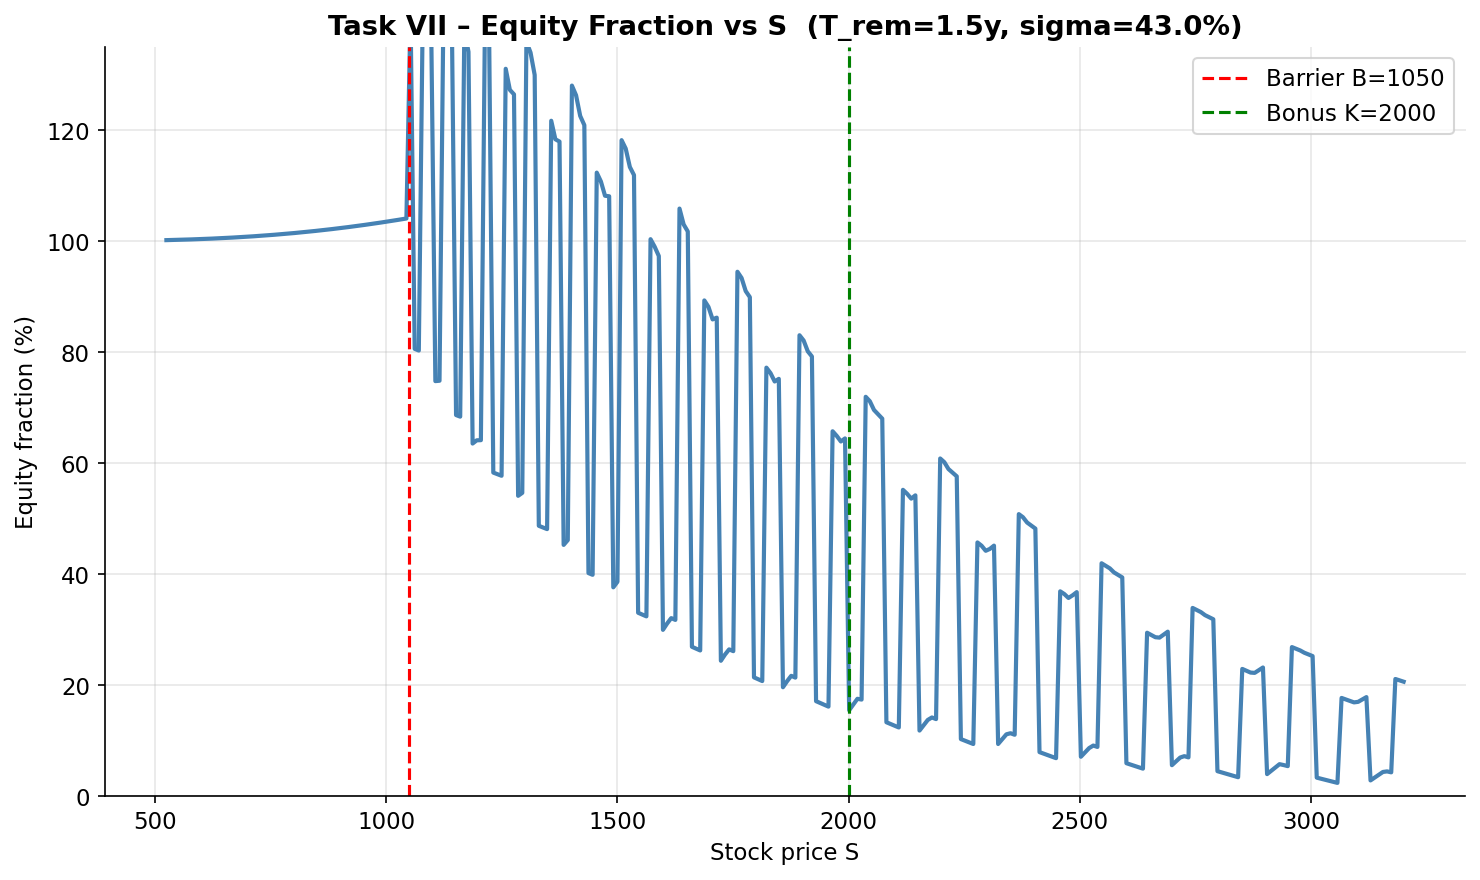

Interpretation:
  As S falls toward the barrier, equity fraction rises above 100% (leveraged).
  The replicating portfolio is short the bond and long more than one share.
  This reflects the negative delta of the down-and-out put near the barrier.
  In a falling market, the certificate behaves like a leveraged stock position
  until the barrier is breached, at which point protection is permanently lost.
  Below the barrier, the certificate has already knocked out and reverts to a
  capped forward, whose equity fraction rises steeply as S falls further —
  the investor bears full downside exposure with no remaining protection.


In [13]:
# ── Equity fraction vs S (static snapshot at T_rem = 1.5y) ───────────────────
T_snap   = 1.5
sig_snap = float(np.median(sigmas_used))

S_cross  = np.linspace(B_cert * 0.50, K_cert * 1.60, 300)
eq_cross = []

for s in S_cross:
    if s <= B_cert:
        # knocked-out: reverts to capped forward = S*exp(-qT) - Call(K_cap)
        # equity fraction = (delta_capped_fwd * s) / fwd_val
        # delta of capped forward = exp(-q*T_snap)
        fwd_val  = s * np.exp(-DIV_YIELD * T_snap) - bs_vanilla_call(s, K_cert, RISK_FREE, DIV_YIELD, sig_snap, T_snap)
        fwd_val  = max(fwd_val, 1e-6)
        delta_ko = np.exp(-DIV_YIELD * T_snap)
        eq_cross.append((delta_ko * s) / fwd_val)
        continue
    g = compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_snap, T_snap)
    V = g['price']
    d = g['delta']
    eq_cross.append((d * s / V) if V > 0 else 1.0)

eq_cross = np.array(eq_cross)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(S_cross, eq_cross * 100, color='steelblue', lw=2)
ax.axvline(B_cert, color='red',   lw=1.5, linestyle='--', label=f'Barrier B={B_cert:.0f}')
ax.axvline(K_cert, color='green', lw=1.5, linestyle='--', label=f'Bonus K={K_cert:.0f}')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Equity fraction (%)')
ax.set_title(f'Task VII – Equity Fraction vs S  (T_rem={T_snap}y, sigma={sig_snap:.1%})',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 135)

plt.tight_layout()
plt.savefig('graphs/equity_fraction_vs_S.png', bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  As S falls toward the barrier, equity fraction rises above 100% (leveraged).')
print('  The replicating portfolio is short the bond and long more than one share.')
print('  This reflects the negative delta of the down-and-out put near the barrier.')
print('  In a falling market, the certificate behaves like a leveraged stock position')
print('  until the barrier is breached, at which point protection is permanently lost.')
print('  Below the barrier, the certificate has already knocked out and reverts to a')
print('  capped forward, whose equity fraction rises steeply as S falls further —')
print('  the investor bears full downside exposure with no remaining protection.')


---
# PART 3 – Portfolio Insurance Strategy

**Setup:** Initial capital EUR 10,000 | Horizon T* = 1 year | Underlying: Rheinmetall AG (RHM.DE)

**Monte Carlo Parameter Sources**

| Parameter | Value | Source |
|-----------|-------|--------|
| Initial capital W₀ | EUR 10,000 | Specified in assignment |
| Investment horizon T* | 1 year | Specified in assignment |
| VaR constraint (Task XI) | 15% | Specified in assignment |
| Underlying S₀ | EUR 1,342.38 | Latest RHM.DE adjusted close from yfinance download ([Yahoo Finance – RHM.DE](https://finance.yahoo.com/quote/RHM.DE)) |
| Historical drift μ | 58.57% p.a. | Mean of daily log-returns (yfinance, Jan 2023 – Apr 2026), annualised × 252. **Note:** reflects Rheinmetall's exceptional defence re-rating; a long-run equity risk premium estimate (e.g. 6–8% over risk-free) would be more conservative for forward-looking use |
| Volatility σ | 39.25% p.a. | Std dev of daily log-returns (yfinance, ibid.), annualised × √252 |
| Risk-free rate r | 2.56% | ECB Svensson (Bundesbank, 01 Jun 2026), T = 1.71y maturity-matched (see Svensson cell above) |
| Paths / steps | 50,000 / 252 | Standard MC precision; seed = 2026 for reproducibility |

In [14]:
# ── Monte Carlo parameters ────────────────────────────────────────────────────
W0       = 10_000
T_star   = 1.0
N_STEPS  = 252
N_PATHS  = 50_000
S0_mc    = float(prices.iloc[-1])
mu_hist  = float(log_returns.mean() * 252)
sigma_mc = float(log_returns.std() * np.sqrt(252))

print('Monte Carlo Setup:')
print(f'  S0       = EUR {S0_mc:.2f}')
print(f'  mu hist  = {mu_hist:.2%}')
print(f'  sigma    = {sigma_mc:.2%}')
print(f'  r        = {RISK_FREE:.2%}')
print(f'  Paths    = {N_PATHS:,}')

# ── Simulate GBM paths (Geometric Brownian Motion) ───────────────────────────
dt_mc = T_star / N_STEPS
np.random.seed(2026)

Z          = np.random.standard_normal((N_PATHS, N_STEPS))
increments = (mu_hist - 0.5 * sigma_mc**2) * dt_mc + sigma_mc * np.sqrt(dt_mc) * Z
log_paths  = np.cumsum(increments, axis=1)
S_paths    = S0_mc * np.exp(np.hstack([np.zeros((N_PATHS, 1)), log_paths]))
S_terminal = S_paths[:, -1]

print(f'Simulation complete.')
print(f'Terminal price range: {S_terminal.min():.1f} – {S_terminal.max():.1f}')

Monte Carlo Setup:
  S0       = EUR 1342.38
  mu hist  = 58.57%
  sigma    = 39.25%
  r        = 2.56%
  Paths    = 50,000
Simulation complete.
Terminal price range: 366.3 – 11780.5


## Task VIII – Performance Analysis (No Risk Management)

--- Task VIII – Unhedged (pure stock) ---
  Mean return       :   79.64%
  Median return     :   66.50%
  Std deviation     :   73.63%
  Skewness          :    1.332
  Sharpe ratio      :    1.047
  95% VaR (loss)    :   12.60%
  95% CVaR (loss)   :   25.33%
  P(loss)           :      9.7%



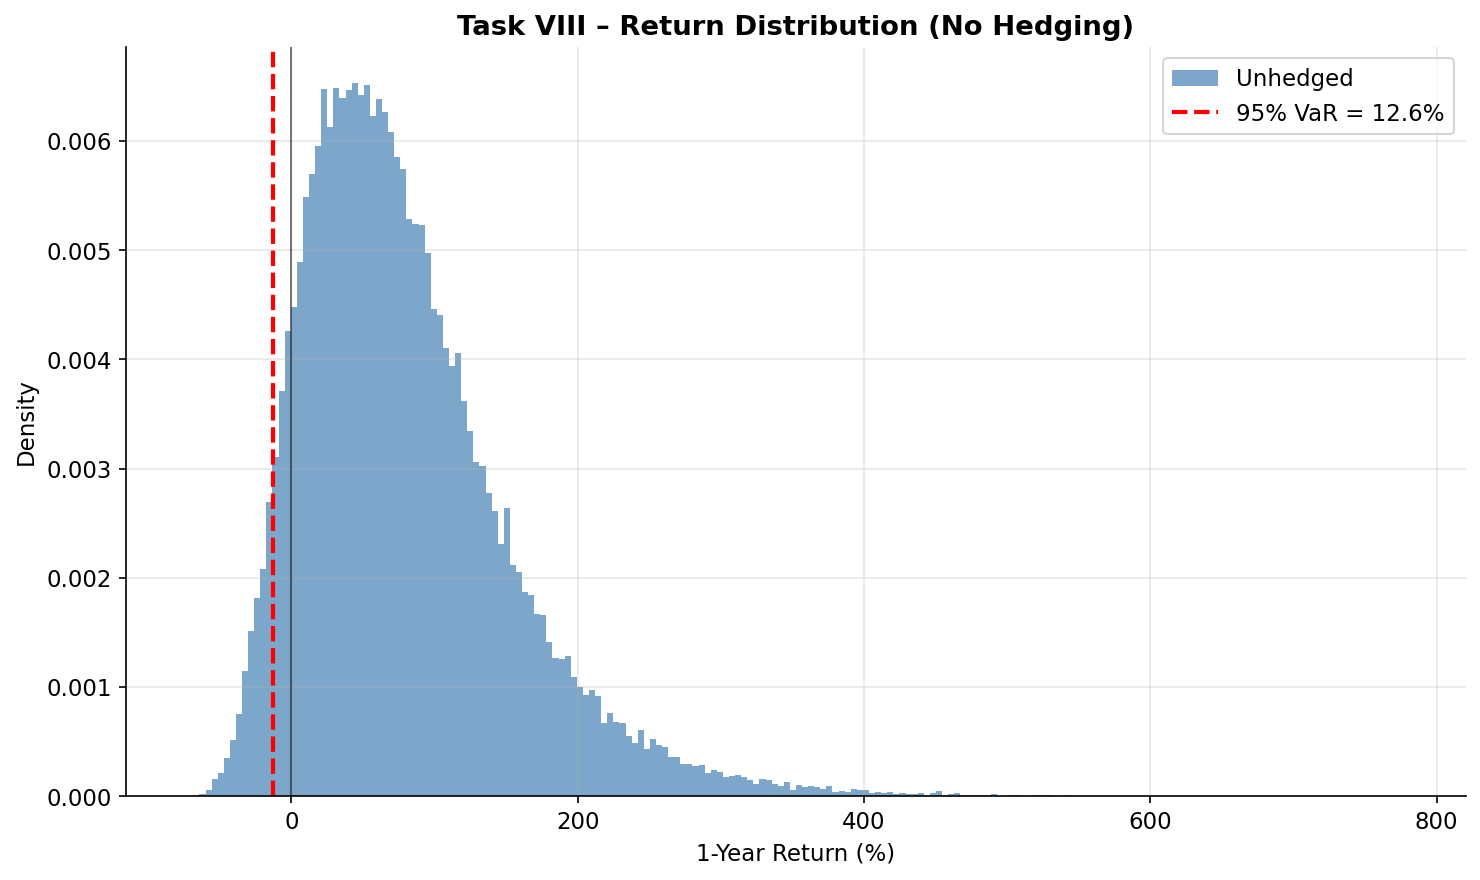

In [15]:
from scipy.stats import skew as _skew

def performance_stats(returns, label=''):
    """Print and return key performance and risk measures."""
    mean_r   = np.mean(returns)
    med_r    = np.median(returns)
    std_r    = np.std(returns)
    skewness = _skew(returns)
    sharpe   = (mean_r - RISK_FREE) / std_r if std_r > 0 else np.nan
    var95    = np.percentile(returns, 5)          # 5th pct = 95% VaR
    cvar95   = np.mean(returns[returns <= var95])
    p_loss   = np.mean(returns < 0) * 100

    if label:
        print(f'--- {label} ---')
    print(f'  Mean return       : {mean_r:>8.2%}')
    print(f'  Median return     : {med_r:>8.2%}')
    print(f'  Std deviation     : {std_r:>8.2%}')
    print(f'  Skewness          : {skewness:>8.3f}')
    print(f'  Sharpe ratio      : {sharpe:>8.3f}')
    print(f'  95% VaR (loss)    : {-var95:>8.2%}')
    print(f'  95% CVaR (loss)   : {-cvar95:>8.2%}')
    print(f'  P(loss)           : {p_loss:>8.1f}%')
    print()
    return {'mean': mean_r, 'std': std_r, 'sharpe': sharpe,
            'var95': var95, 'cvar95': cvar95, 'p_loss': p_loss,
            'skewness': skewness}


returns_unhedged = S_terminal / S0_mc - 1
stats_uh = performance_stats(returns_unhedged, 'Task VIII – Unhedged (pure stock)')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(returns_unhedged * 100, bins=200, density=True,
        color='steelblue', alpha=0.7, label='Unhedged')
ax.axvline(stats_uh['var95'] * 100, color='red', lw=2, linestyle='--',
           label=f"95% VaR = {-stats_uh['var95']:.1%}")
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task VIII – Return Distribution (No Hedging)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/mc_unhedged.png', bbox_inches='tight')
plt.show()


**Note on drift assumption:** μ = 58.57% p.a. reflects Rheinmetall's exceptional recent
return, driven by the European defence re-rating post-2022. Using this as the GBM drift
significantly overstates the expected return for a forward-looking simulation — a long-run
equity risk premium of 6–8% on top of the risk-free rate would be more conservative and
arguably more appropriate for portfolio planning. Results should therefore be interpreted
as conditional on the recent return environment continuing.

**On the return distribution:** The log-normal GBM produces a right-skewed return
distribution (skewness ≈ +1.33). The median return (66.5%) lies below the mean (79.6%),
confirming positive skew — the mean is pulled up by a small number of very large upside
paths. This is a well-known property of GBM and is why median and VaR are both reported
alongside the mean.

## Task IX – Portfolio Insurance with Put Options

In [16]:
def insured_return(S_term, S0, alpha, K_put, r, q, sigma_price, T, W=10_000):
    """Return distribution for (1-alpha)*stock + alpha*puts portfolio."""
    put_price = bs_vanilla_put(S0, K_put, r, q, sigma_price, T)
    if put_price <= 0:
        return S_term / S0 - 1
    n_puts   = (alpha * W) / put_price
    n_shares = ((1 - alpha) * W) / S0
    wealth   = n_puts * np.maximum(K_put - S_term, 0) + n_shares * S_term
    return wealth / W - 1


alpha_vals  = [0.05, 0.10, 0.15, 0.20]
strike_pcts = [0.90, 0.95, 1.00, 1.05]

results_ix = {}
rows = []

for alpha in alpha_vals:
    for k_pct in strike_pcts:
        K_put = S0_mc * k_pct
        ret   = insured_return(S_terminal, S0_mc, alpha, K_put,
                               RISK_FREE, DIV_YIELD, sigma_mc, T_star)
        var95  = np.percentile(ret, 5)
        cvar95 = np.mean(ret[ret <= var95])
        std_r  = np.std(ret)
        sharpe = (np.mean(ret) - RISK_FREE) / std_r if std_r > 0 else np.nan

        results_ix[(alpha, k_pct)] = ret
        rows.append({
            'Alpha': f'{alpha:.0%}',
            'Strike': f'{k_pct:.0%}',
            'Mean': f"{np.mean(ret):.2%}",
            'Std': f"{std_r:.2%}",
            'Sharpe': f'{sharpe:.3f}',
            '95% VaR': f"{-var95:.2%}",
            '95% CVaR': f"{-cvar95:.2%}",
            'P(loss)': f"{np.mean(ret<0)*100:.1f}%"
        })

print('Task IX – Insurance Strategy Summary')
print(pd.DataFrame(rows).to_string(index=False))

Task IX – Insurance Strategy Summary
Alpha Strike   Mean    Std Sharpe 95% VaR 95% CVaR P(loss)
   5%    90% 71.06% 69.38%  0.987  15.63%   21.17%   12.2%
   5%    95% 71.12% 69.30%  0.989  13.83%   20.66%   12.2%
   5%   100% 71.18% 69.23%  0.991  12.69%   20.47%   12.2%
   5%   105% 71.25% 69.16%  0.993  11.97%   20.45%   12.2%
  10%    90% 62.48% 65.18%  0.919  16.70%   17.96%   15.1%
  10%    95% 62.59% 65.04%  0.923  15.06%   15.99%   15.1%
  10%   100% 62.72% 64.89%  0.927  12.79%   15.60%   15.1%
  10%   105% 62.86% 64.74%  0.931  11.35%   15.58%   15.1%
  15%    90% 53.89% 61.07%  0.841  17.58%   20.53%   18.6%
  15%    95% 54.07% 60.85%  0.847  15.53%   17.44%   18.9%
  15%   100% 54.26% 60.62%  0.853  13.22%   14.15%   18.9%
  15%   105% 54.47% 60.40%  0.859  10.73%   10.74%   18.9%
  20%    90% 45.31% 57.04%  0.749  21.01%   24.40%   22.4%
  20%    95% 45.55% 56.75%  0.758  18.69%   21.37%   22.5%
  20%   100% 45.80% 56.45%  0.766  16.22%   18.11%   22.7%
  20%   105% 46.08%

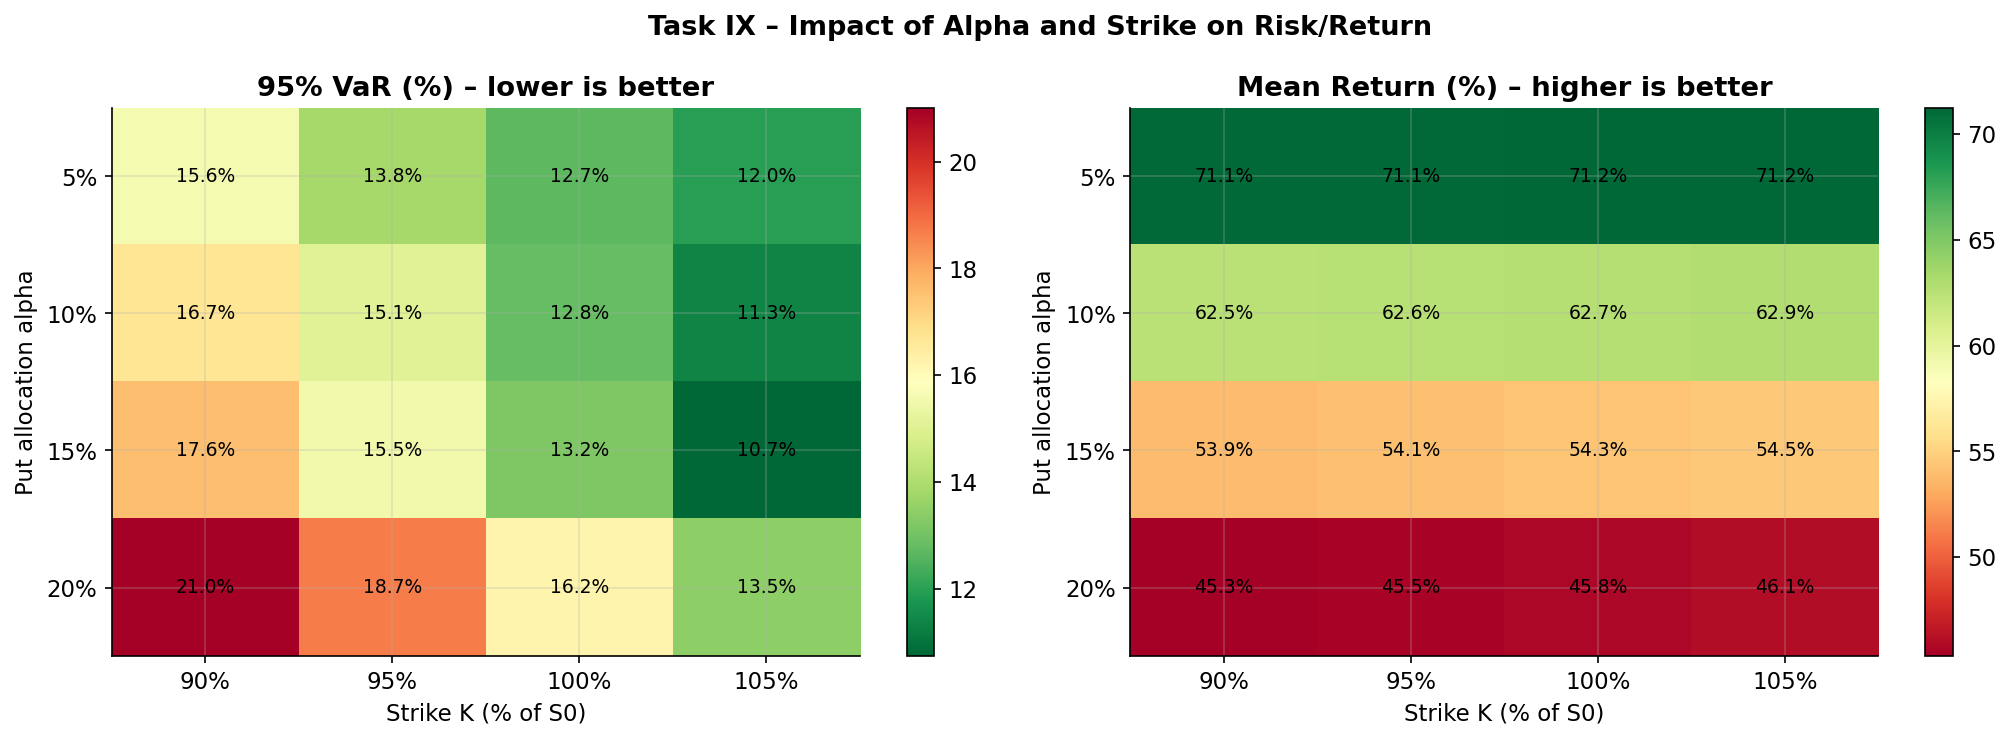

In [17]:
# ── Heatmaps: VaR and Mean Return ────────────────────────────────────────────
var_mat  = np.array([[-np.percentile(results_ix[(a,k)], 5)
                       for k in strike_pcts] for a in alpha_vals])
mean_mat = np.array([[np.mean(results_ix[(a,k)])
                       for k in strike_pcts] for a in alpha_vals])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, cmap in [
        (ax1, var_mat  * 100, '95% VaR (%) – lower is better', 'RdYlGn_r'),
        (ax2, mean_mat * 100, 'Mean Return (%) – higher is better', 'RdYlGn')]:
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(strike_pcts)))
    ax.set_xticklabels([f'{k:.0%}' for k in strike_pcts])
    ax.set_yticks(range(len(alpha_vals)))
    ax.set_yticklabels([f'{a:.0%}' for a in alpha_vals])
    ax.set_xlabel('Strike K (% of S0)')
    ax.set_ylabel('Put allocation alpha')
    ax.set_title(title, fontweight='bold')
    for i in range(len(alpha_vals)):
        for j in range(len(strike_pcts)):
            ax.text(j, i, f'{mat[i,j]:.1f}%', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle('Task IX – Impact of Alpha and Strike on Risk/Return',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('graphs/insurance_heatmap.png', bbox_inches='tight')
plt.show()

## Task X – Stress Scenario Analysis

  TASK X – Stress Analysis  (alpha=10%, K=95% of S0)
Scenario                      Mean    VaR95    CVaR95  P(loss)
-----------------------------------------------------------------
Baseline                   62.59%  15.06%    15.99%    15.1%
Vol +5pp                   62.47%  15.89%    18.21%    15.1%
Vol -5pp                   62.76%  13.35%    13.98%    15.1%
-20% shock at T/2          32.14%  16.33%    17.08%    32.4%


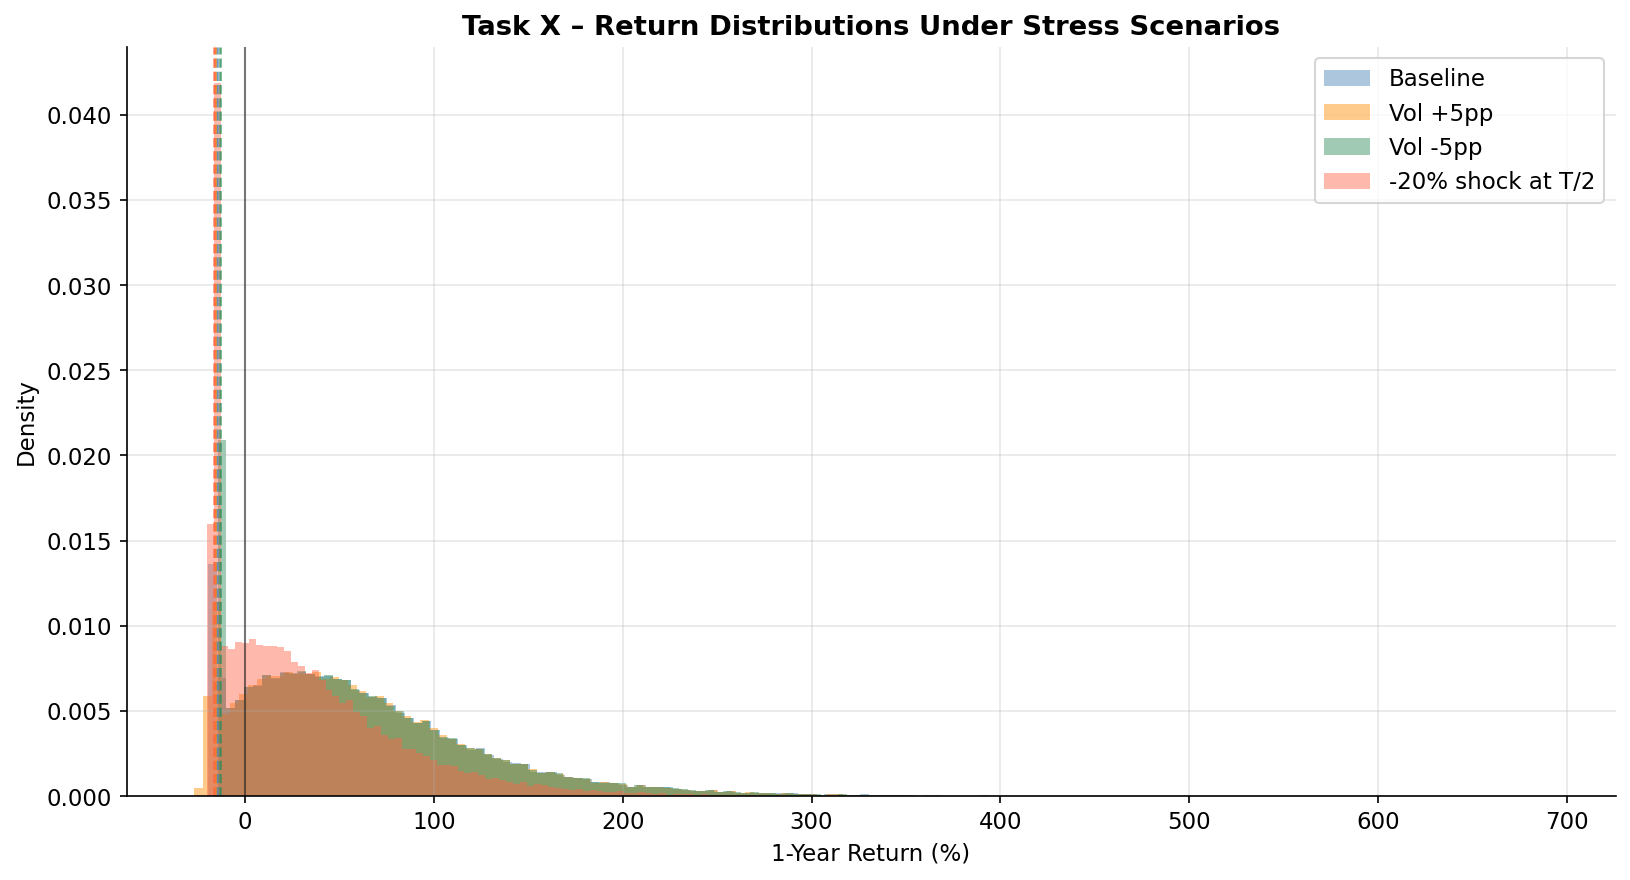

In [18]:
# ── Chosen allocation for stress test ────────────────────────────────────────
alpha_s = 0.10    # 10% in puts
k_pct_s = 0.95    # strike = 95% of S0
K_s     = S0_mc * k_pct_s

# Baseline
ret_base   = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc, T_star)

# Stress 1: pricing vol +5pp
ret_vol_up = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc + 0.05, T_star)

# Stress 2: pricing vol -5pp
ret_vol_dn = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc - 0.05, T_star)

# Stress 3: -20% price shock at T/2
S_paths_shock = S_paths.copy()
mid           = N_STEPS // 2
S_paths_shock[:, mid:] *= 0.80
S_term_shock  = S_paths_shock[:, -1]
ret_shock     = insured_return(S_term_shock, S0_mc, alpha_s, K_s,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)

scenarios = {
    'Baseline':          ret_base,
    'Vol +5pp':          ret_vol_up,
    'Vol -5pp':          ret_vol_dn,
    '-20% shock at T/2': ret_shock,
}

print('=' * 65)
print(f'  TASK X – Stress Analysis  (alpha={alpha_s:.0%}, K={k_pct_s:.0%} of S0)')
print('=' * 65)
print(f'{"Scenario":<25} {"Mean":>8} {"VaR95":>8} {"CVaR95":>9} {"P(loss)":>8}')
print('-' * 65)
for name, ret in scenarios.items():
    m    = np.mean(ret)
    v95  = np.percentile(ret, 5)
    cv95 = np.mean(ret[ret <= v95])
    pl   = np.mean(ret < 0) * 100
    print(f'{name:<25} {m:>7.2%} {-v95:>7.2%}  {-cv95:>8.2%} {pl:>7.1f}%')

# ── Stress distribution chart with VaR vertical lines ────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
colors_sc = ['steelblue', 'darkorange', 'seagreen', 'tomato']
for (name, ret), color in zip(scenarios.items(), colors_sc):
    ax.hist(ret * 100, bins=150, density=True, alpha=0.45, color=color, label=name)
    v = np.percentile(ret, 5)
    ax.axvline(v * 100, color=color, lw=1.2, linestyle='--', alpha=0.8)
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task X – Return Distributions Under Stress Scenarios', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/stress_scenarios.png', bbox_inches='tight')
plt.show()


At the baseline allocation (α = 10%, K = 95% of S₀), the 95% VaR is 15.1% — close to the regulatory limit. Higher implied volatility (+5pp) raises the put premium at purchase, so the fixed 10% budget buys fewer contracts and VaR worsens to 15.9%; lower volatility (−5pp) has the opposite effect, tightening the floor to 13.4% VaR. The −20% mid-horizon price shock is the most damaging scenario: mean return collapses to 32% and P(loss) more than doubles to 32.4%, because the residual 90% stock position absorbs most of the crash — the put hedge provides only partial relief since the shock occurs before maturity and the put still retains intrinsic value at T/2.

## Task XI – Capital Requirement (VaR Constraint)

Optimal allocation:
  alpha*          = 9.77%  (fraction in puts)
  Resulting VaR95 = 15.00%  (target: 15.00%)
  Expected return = 62.98%
  Sharpe ratio    = 0.926


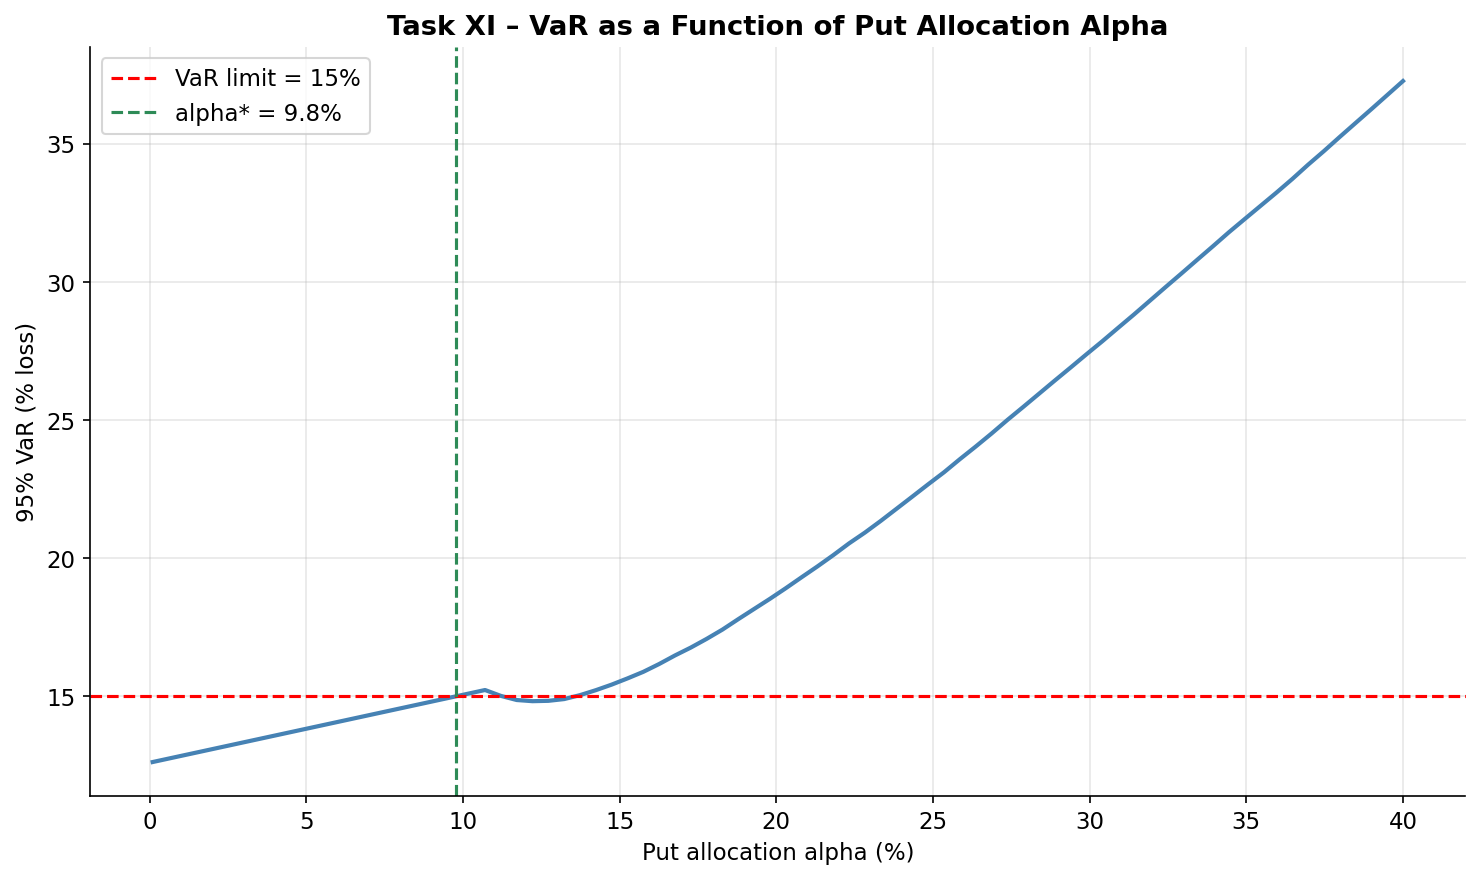

In [19]:
# ── Find alpha* such that 95% VaR = exactly 15% ──────────────────────────────
VAR_LIMIT = -0.15    # 95% VaR must not exceed 15% loss
K_xi      = S0_mc * 0.95

def var95_fn(alpha):
    ret = insured_return(S_terminal, S0_mc, alpha, K_xi,
                         RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    return np.percentile(ret, 5)

# Scan
alpha_scan = np.linspace(0.001, 0.40, 80)
var_scan   = [var95_fn(a) for a in alpha_scan]

# Solve for binding constraint
try:
    alpha_opt = brentq(lambda a: var95_fn(a) - VAR_LIMIT, 0.001, 0.40)
    var_opt   = var95_fn(alpha_opt)
    ret_opt   = insured_return(S_terminal, S0_mc, alpha_opt, K_xi,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    print(f'Optimal allocation:')
    print(f'  alpha*          = {alpha_opt:.2%}  (fraction in puts)')
    print(f'  Resulting VaR95 = {-var_opt:.2%}  (target: 15.00%)')
    print(f'  Expected return = {np.mean(ret_opt):.2%}')
    print(f'  Sharpe ratio    = {(np.mean(ret_opt) - RISK_FREE) / np.std(ret_opt):.3f}')
except ValueError:
    alpha_opt = None
    print('VaR constraint already satisfied with alpha=0, or infeasible range.')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alpha_scan * 100, np.array(var_scan) * (-100), color='steelblue', lw=2)
ax.axhline(15, color='red', lw=1.5, linestyle='--', label='VaR limit = 15%')
if alpha_opt is not None:
    ax.axvline(alpha_opt * 100, color='seagreen', lw=1.5, linestyle='--',
               label=f'alpha* = {alpha_opt:.1%}')
ax.set_xlabel('Put allocation alpha (%)')
ax.set_ylabel('95% VaR (% loss)')
ax.set_title('Task XI – VaR as a Function of Put Allocation Alpha', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/var_constraint.png', bbox_inches='tight')
plt.show()

Allocating α* ≈ 9.8% of the initial €10,000 to 95%-strike put options fully exhausts the VaR budget: the portfolio's 95% one-year VaR lands exactly at the 15% regulatory ceiling, meaning no additional put spending could reduce tail risk further without breaching the constraint from below. Over-hedging (α > α*) would lower expected return unnecessarily, while under-hedging (α < α*) leaves residual tail risk on the table; α* is the unique allocation that makes the VaR constraint binding rather than slack.

---
## Output Files Summary

| File | Task | Content |
|------|------|---------|
| `graphs/payoff_profile.png` | III | Payoff diagram |
| `graphs/stock_data.png` | Data | Price history + vol |
| `graphs/valuation_comparison.png` | V | Model vs market + errors |
| `graphs/greeks.png` | VI | Delta, Gamma, Vega, Theta |
| `graphs/replicating_portfolio_time.png` | VII | Daily delta + equity fraction |
| `graphs/equity_fraction_vs_S.png` | VII | Equity fraction vs S |
| `graphs/mc_unhedged.png` | VIII | Unhedged return distribution |
| `graphs/insurance_heatmap.png` | IX | Alpha x Strike heatmap |
| `graphs/stress_scenarios.png` | X | Stress scenario distributions |
| `graphs/var_constraint.png` | XI | VaR vs alpha curve |